# Capstone — Which fifty pages should an editor open first?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/An3DCu/ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Lane: Bleed Tracker** — rank a client portfolio's pages by how likely each one is to lose search
impressions next month, so one editor can work down a capped queue.

This notebook is the paper. Every number the deployed page prints is computed here, from the
warehouse, in one top-to-bottom run.

**What is new here, and only here: the sealed month is opened.** Weeks 3–7 developed and audited
this lane on `2026-01` through `2026-05` and left **June 2026 shut** — the panel's final month, and
the natural outcome window of any past→future label in this lane. w06 closed it deliberately; w07
pre-registered the release checks and the promotion rule so they could be run **once**, on a month
neither the rule nor the model has ever seen. Section 3 runs the label-free pre-release gate on the
sealed release. Section 4 opens the label and reports what happened.

| section | what it holds | the paper section it feeds |
|---|---|---|
| 0 | setup, the six-month panel, and nine cross-checks against four weeks of receipts | reproducibility |
| 1 | the question and the decision it supports | introduction / problem |
| 2 | the release, the tables, the windows, the exclusions | data |
| 3 | features, label, rule, model, gates, validation design, leakage audit, **the pre-release gate** | methodology |
| 4 | **the sealed month, opened once** — model vs baseline on the same rows | results |
| 5 | what this work cannot claim | limitations |
| 6 | the ranked action playbook | ranked recommendations |
| 7 | the figures, the queue and the receipts the page embeds | artifacts |
| ML-12 | demo outline, social cut, employer summary | repurposing |


## Abstract

> **Can decision-time search-console signals rank a client portfolio so that the fifty pages an
> editor opens first are the ones about to lose search impressions?**

**The data.** The FlyRank ML internship warehouse: 78,835,655 daily page-rows, 2025-01-27 →
2026-06-30. Each month I score 82,570 pages across 24 pseudonymised clients. Five features, every
one measured inside the feature month. The label — a drop of more than 20% in impressions — is
measured entirely in the month after.

**The method.** A frozen hand-written rule against a tuned random forest, on identical rows, in the
same run, at precision@50. The split is grouped by client *and* forward in time. The panel's final
month stayed sealed until release checks I had written a week earlier passed it, without ever seeing
a label.

**The result.** On that sealed month the rule put **49 of 50** correct pages in front of the editor,
against a **73.6% base rate**. The forest put 50 of 50. Across four forward deployments the gap
between them runs −10, +8, −2, +2 points: a mean of −0.5, with a 90% interval of −6.0 to +5.0. The
pre-registered promotion rule declined to give the model editorial slots — for the third time in
four months.

**What it is for.** Decision support, not automation. Fifty ranked pages, each with a reason a
person can argue with and a guardrail. And next to every score, the margin over the month it was
measured in — because that margin *fell* from +68.6 to +24.4 points while the precision rose.

## 0. Setup — connection, lane constants, four weeks of receipts

Nothing about the data, the rule or the model is re-chosen in this notebook. The constants below
are the w03 data contract's, the rule is w04's frozen one, the forest is w05's chosen one, the
split is the same `GroupShuffleSplit(test_size=0.3, random_state=42)` grouped by client, and the
metric is the precision@50 this lane declared in w01 before any model was fitted.

The warehouse is on Hugging Face. DuckDB reads only the columns and month partitions the SQL
touches, so nothing here downloads the 79 million rows of the daily fact table. The read token comes from a Colab Secret, an
environment variable, or a gitignored local `.env` — never pasted into a cell, because this repo
is public.

In [1]:
import importlib.util, subprocess, sys

for pkg in ("duckdb", "huggingface_hub"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import json, os, pathlib, warnings
import duckdb, numpy as np, pandas as pd, sklearn
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
SEED = 42          # same seed as w03, w04, w05, w06 and w07 - same split, same numbers on a rerun

print(f"python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__} | duckdb {duckdb.__version__} | "
      f"matplotlib {matplotlib.__version__}")


def load_hf_token():
    if os.environ.get("HF_TOKEN"):
        return os.environ["HF_TOKEN"], "environment variable"
    for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        env_file = parent / ".env"
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                if line.strip().startswith("HF_TOKEN="):
                    return line.split("=", 1)[1].strip().strip("\"'"), "local .env (gitignored)"
    try:
        from google.colab import userdata
        return userdata.get("HF_TOKEN"), "Colab Secret"
    except Exception:
        pass
    raise RuntimeError("No HF_TOKEN found. Set a Colab Secret named HF_TOKEN (read token).")


HF_TOKEN, token_source = load_hf_token()
print(f"HF read token loaded from: {token_source}")

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
DIM_CLIENTS = f"read_parquet('{REL}/dim_clients.parquet')"
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"


def hf_sql(query, tries=6, base_wait=20):
    import time
    for attempt in range(tries):
        try:
            return con.sql(query).df()
        except Exception as exc:
            if "429" not in str(exc) or attempt == tries - 1:
                raise
            wait = base_wait * (attempt + 1)
            print(f"  hub returned HTTP 429, waiting {wait}s, retry {attempt + 1}/{tries - 1}")
            time.sleep(wait)


def fact(month):
    """One month partition of fact_content_daily_performance."""
    return f"read_parquet('{REL}/fact_content_daily_performance/month={month}/*.parquet')"


# --- lane constants: copied unchanged from w03 / w04 / w05 / w06 / w07 -------------------------
FEATURE_MONTH = "2026-03"     # w05's frozen decision moment - the anchor every week checks against
LABEL_MONTH   = "2026-04"
DECISION_DATE = "2026-03-31"
MIN_HISTORY   = "2026-01-01"  # client must have GSC history starting on/before this
MIN_IMP       = 100           # a page needs measurable search demand in the feature month
DECLINE_DROP  = 0.20          # "declining" = next month's impressions >20% below this month's
TOP_K         = 50            # editorial capacity: the queue is 50 pages long

CONTRACT_FEATURES = ["log_imp_mar", "active_days", "pos_mar", "ctr_mar", "momentum_in_month"]
FEATURES = CONTRACT_FEATURES  # five, and nothing is added in the capstone either

# --- the sealed release. This is the only notebook in the track allowed to open it. ------------
SEALED_FEATURE_MONTH = "2026-05"   # decision moment of the sealed release: 2026-05-31
SEALED_LABEL_MONTH   = "2026-06"   # opened ONCE, in section 4, as a label and never as a feature
SEALED_DECISION_DATE = "2026-05-31"

MONTHS = ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"]
MID = {"2026-01": "2026-01-17", "2026-02": "2026-02-15", "2026-03": "2026-03-17",
       "2026-04": "2026-04-16", "2026-05": "2026-05-17", "2026-06": "2026-06-16"}
DAYS_IN_MONTH = {"2026-01": 31, "2026-02": 28, "2026-03": 31, "2026-04": 30,
                 "2026-05": 31, "2026-06": 30}
OPEN_PAIRS  = [("2026-01", "2026-02"), ("2026-02", "2026-03"),
               ("2026-03", "2026-04"), ("2026-04", "2026-05")]
SEALED_PAIR = (SEALED_FEATURE_MONTH, SEALED_LABEL_MONTH)
PAIRS       = OPEN_PAIRS + [SEALED_PAIR]

# --- w07's playbook constants: policy, declared before anything is measured with them ----------
RULE_SLOTS    = TOP_K       # the editor's whole review budget goes to the frozen rule
TRIAL_SHADOW  = 10          # the model's queue rides along as SHADOW items, never an editor slot
ALT_SPLIT     = (40, 10)    # the in-budget alternative w07 priced: 40 rule slots + 10 trial slots
RISER_GATE    = 1.20        # w04 s1c: pages at/above this declined BELOW the base rate
SPIKE_GATE    = 0.25        # w04 s3: one day holding >=25% of the month is a measurement suspicion
COVERAGE_GATE = 25          # live on fewer than 25 of the month's days: coverage can fake a slide
assert sum(ALT_SPLIT) == TOP_K

# --- w07's pre-registered thresholds. Written down BEFORE the sealed month; used as written. ---
T_POPULATION       = 0.20   # +/-20% change in the number of scorable pages -> hold the release
T_PSI              = 0.25   # borrowed convention, on per-day-normalised features -> hold
T_BASE_RATE        = 0.10   # 10 points of base-rate move -> cross-month comparisons are void
T_QUEUE_MARGIN     = 0.10   # the queue must clear its own month's base rate by 10 points
T_TRIAL_MONTHS     = 2      # consecutive months of non-positive trial lift -> close the shadow queue
T_PROMOTION_MONTHS = 2      # consecutive months of no precision cost -> the trial earns real slots
PSI_WATCH, PSI_HOLD = 0.10, 0.25


def precision_at_k_fair(df, score_col, label_col="label_declining", k=TOP_K):
    """w05's tie-fair metric, unchanged: ties are not allowed to choose the queue."""
    s = df[score_col].to_numpy()
    y = df[label_col].to_numpy()
    cut = np.sort(s)[::-1][k - 1]
    above, tied = s > cut, s == cut
    slots = k - int(above.sum())
    return float((y[above].sum() + slots * y[tied].mean()) / k)


def p50(df, score_col):
    return precision_at_k_fair(df, score_col)


def wilson(k, n, z=1.645):
    """90% Wilson interval - because 49 correct out of 50 is not 0.98 give or take nothing."""
    p = k / n
    denom = 1 + z * z / n
    centre = p + z * z / (2 * n)
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return float((centre - half) / denom), float((centre + half) / denom)


out_dir = pathlib.Path("../outputs")
fig_dir = pathlib.Path("../figures")
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

prev = {w: json.loads((out_dir / f"{w}_receipts.json").read_text(encoding="utf-8"))
        for w in ["w03_data_contract", "w04_baseline_score", "w05_model",
                  "w06_validation_audit", "w07_action_playbook"]}
print(f"\nreceipts loaded from earlier weeks: {', '.join(prev)}")
print(f"anchor deployment (checked against those receipts): {FEATURE_MONTH} -> {LABEL_MONTH}")
print(f"SEALED release, opened once in this notebook: features {SEALED_FEATURE_MONTH} "
      f"(decision moment {SEALED_DECISION_DATE}), label {SEALED_LABEL_MONTH}")

receipts = {
    "lane": "bleed_tracker", "seed": SEED, "top_k": TOP_K,
    "sklearn_version": sklearn.__version__, "contract_features": CONTRACT_FEATURES,
    "months_opened": MONTHS, "sealed_feature_month": SEALED_FEATURE_MONTH,
    "sealed_label_month": SEALED_LABEL_MONTH,
    "gates": {"riser": RISER_GATE, "spike_share": SPIKE_GATE,
              "min_active_days": COVERAGE_GATE, "min_impressions_upstream": MIN_IMP},
    "pre_registered_thresholds": {
        "population": T_POPULATION, "psi": T_PSI, "base_rate": T_BASE_RATE,
        "queue_margin": T_QUEUE_MARGIN, "trial_close_months": T_TRIAL_MONTHS,
        "promotion_months": T_PROMOTION_MONTHS,
        "source": "w07_action_playbook_receipts.json - written before the sealed month was opened"}}

python 3.12.6 | numpy 1.26.4 | pandas 2.3.3 | scikit-learn 1.9.0 | duckdb 1.5.4 | matplotlib 3.10.9
HF read token loaded from: local .env (gitignored)

receipts loaded from earlier weeks: w03_data_contract, w04_baseline_score, w05_model, w06_validation_audit, w07_action_playbook
anchor deployment (checked against those receipts): 2026-03 -> 2026-04
SEALED release, opened once in this notebook: features 2026-05 (decision moment 2026-05-31), label 2026-06


### 0b. Six months of the same slice — and the wall between features and labels

One query per month, identical in shape to w03's, w06's and w07's: page-level GSC aggregates for
every day the warehouse reports as available, grouped to one row per client × content × month,
`ORDER BY content_hash_id` so a parallel `GROUP BY` cannot hand back a different row order on every
rerun (w05 s0b measured what that costs — bootstrap draws and tie-breaks both move with row order).

The population rules — 100+ impressions, client history from before 2026-01-01 — apply to the
**feature** month only. The label lookup stays unfiltered, because a page that stops appearing next
month is an outcome, not a missing value.

**The sealed release is handled differently on purpose.** `build_features` and `attach_label` are
two separate functions, so the sealed release's frame can be built, gated and released in section 3
*without an outcome column existing on it*. Section 4 is the only place `attach_label` is called
with `2026-06`. That ordering is the whole point of a sealed evaluation, and here it is legible
from the cell order rather than taken on trust.

In [2]:
panel_parts = []
for m in MONTHS:
    q = f"""
        SELECT '{m}' AS month,
               f.client_hash_id,
               f.content_hash_id,
               SUM(f.gsc_impressions)                                            AS imp,
               SUM(f.gsc_clicks)                                                 AS clk,
               COUNT(*) FILTER (f.gsc_impressions > 0)                           AS active_days,
               SUM(f.gsc_sum_position)                                           AS sum_pos,
               MAX(f.gsc_impressions)                                            AS max_day_imp,
               SUM(f.gsc_impressions) FILTER (f.report_date >= DATE '{MID[m]}')  AS imp_late,
               SUM(f.gsc_impressions) FILTER (f.report_date <  DATE '{MID[m]}')  AS imp_early
        FROM {fact(m)} f
        WHERE f.gsc_data_available IS TRUE
        GROUP BY 1, 2, 3
        ORDER BY f.content_hash_id
    """
    part = hf_sql(q)
    assert not part.content_hash_id.duplicated().any(), f"content_hash_id is not unique in {m}"
    panel_parts.append(part)
    flag = "   <- SEALED: read as a LABEL only, never as a feature" if m == SEALED_LABEL_MONTH else ""
    print(f"{m}: {len(part):>7,} page-months pulled{flag}")

panel = pd.concat(panel_parts, ignore_index=True)
eligible_clients = set(hf_sql(
    f"SELECT client_hash_id FROM {DIM_CLIENTS} WHERE gsc_data_start <= DATE '{MIN_HISTORY}'"
).client_hash_id)
n_clients_total = int(hf_sql(f"SELECT COUNT(*) AS n FROM {DIM_CLIENTS}").n.iloc[0])
print(f"\npanel: {len(panel):,} page-months over {len(MONTHS)} months | clients with GSC history "
      f"from before {MIN_HISTORY}: {len(eligible_clients)} of {n_clients_total}")


def build_features(feature_month):
    """The decision-time frame: one row per page, five contract features, NO outcome column.

    Everything here is measured inside `feature_month`, so it is knowable on that month's last day.
    """
    f = panel[(panel.month == feature_month)
              & panel.client_hash_id.isin(eligible_clients)
              & (panel.imp >= MIN_IMP)].copy()
    f["imp_mar"] = f.imp                                    # kept under w03's column name
    f["pos_mar"] = f.sum_pos / f.imp
    f["ctr_mar"] = f.clk / f.imp
    f["momentum_in_month"] = f.imp_late / f.imp_early.replace(0, np.nan)
    f["has_first_half_traffic"] = f.momentum_in_month.notna().astype(int)
    f["momentum_in_month"] = f.momentum_in_month.fillna(1.0)
    f["log_imp_mar"] = np.log1p(f.imp)
    f["spike_share"] = f.max_day_imp / f.imp
    assert f[FEATURES].isna().sum().sum() == 0, "a null reached the feature matrix"
    return f.reset_index(drop=True)


def attach_label(frame, label_month):
    """Join the outcome. The ONLY function that reads a month after the decision moment."""
    lab = (panel.loc[panel.month == label_month, ["content_hash_id", "imp"]]
                .rename(columns={"imp": "imp_next"}))
    fr = frame.merge(lab, on="content_hash_id", how="left")
    assert len(fr) == len(frame), "the label join changed the row count"
    fr["seen_next_month"] = fr.imp_next.notna().astype(int)
    fr["imp_next"] = fr.imp_next.fillna(0)
    fr["label_declining"] = (fr.imp_next < (1 - DECLINE_DROP) * fr.imp).astype(int)
    return fr


# The four month pairs w03-w07 were allowed to open.
pairs = {f"{a}->{b}": attach_label(build_features(a), b) for a, b in OPEN_PAIRS}
for k, v in pairs.items():
    print(f"{k}: {len(v):>6,} decision rows | {v.client_hash_id.nunique():>2} clients | "
          f"base rate {v.label_declining.mean():.2%}")

# The sealed release's feature frame. No outcome on it, and none joined until section 4.
sealed_features = build_features(SEALED_FEATURE_MONTH)
no_outcome = not {"label_declining", "imp_next", "seen_next_month"} & set(sealed_features.columns)
print(f"\nSEALED feature frame built from {SEALED_FEATURE_MONTH}: {len(sealed_features):,} decision "
      f"rows | {sealed_features.client_hash_id.nunique()} clients | carries no outcome column: {no_outcome}")
assert no_outcome, "the sealed frame must not carry an outcome before section 4"

2026-01: 121,544 page-months pulled


2026-02: 153,559 page-months pulled


2026-03: 176,738 page-months pulled


2026-04: 194,760 page-months pulled


2026-05: 237,910 page-months pulled


2026-06: 208,636 page-months pulled   <- SEALED: read as a LABEL only, never as a feature



panel: 1,093,147 page-months over 6 months | clients with GSC history from before 2026-01-01: 40 of 104


2026-01->2026-02: 63,909 decision rows | 28 clients | base rate 25.12%
2026-02->2026-03: 72,745 decision rows | 28 clients | base rate 22.90%
2026-03->2026-04: 85,453 decision rows | 27 clients | base rate 53.78%
2026-04->2026-05: 85,518 decision rows | 27 clients | base rate 53.77%

SEALED feature frame built from 2026-05: 82,570 decision rows | 24 clients | carries no outcome column: True


### 0c. The frozen rule, the chosen model, and nine cross-checks against four weeks of receipts

A capstone that cannot reproduce the numbers it is built on is a summary, not a paper. So the
anchor deployment (`2026-03` → `2026-04`, grouped split, 9 held-out clients) is rebuilt from the
warehouse here and asserted against nine values committed in `work/outputs/*.json` across w03, w04,
w05 and w06. If any of them had drifted, every comparison below would be measuring a different
experiment.

The rule is pasted back verbatim — constants and all — because a baseline quoted from last month's
markdown is a claim, not a comparison. Its one fitted quantity (the median CTR of each position
band) is re-derived on training clients only, exactly as w04 derived it.

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ---------------- w04's rule, still frozen: nothing below this line was retuned ----------------
POS_BANDS, POS_NAMES = [0, 3, 10, 20, np.inf], ["1-3", "4-10", "11-20", "21+"]
SLIP_GATE, POS_REACH, W_UNDERCLICK, W_REACHABLE = 0.8, 20, 1.0, 0.5


def band_median_ctr(df):
    """The rule's only fitted quantity, learned on training rows only."""
    return (df.assign(pos_band=pd.cut(df.pos_mar, POS_BANDS, labels=POS_NAMES))
              .groupby("pos_band", observed=True)["ctr_mar"].median())


def score_pages(df, band_med_ctr):
    """w04's baseline action score: severity x size x underclicking x reachability."""
    band       = pd.cut(df.pos_mar, POS_BANDS, labels=POS_NAMES)
    severity   = (1 - df.momentum_in_month / SLIP_GATE).clip(lower=0)
    underclick = (df.ctr_mar < band.map(band_med_ctr).astype(float)).astype(int)
    reachable  = ((df.pos_mar >= 1) & (df.pos_mar <= POS_REACH)).astype(int)
    return severity * np.log1p(df.imp_mar) * (1 + W_UNDERCLICK * underclick) * (1 + W_REACHABLE * reachable)


def rule_reason(df, band_med_ctr):
    """w04's reason codes: the sentence a human reads next to the page."""
    band       = pd.cut(df.pos_mar, POS_BANDS, labels=POS_NAMES)
    severity   = (1 - df.momentum_in_month / SLIP_GATE).clip(lower=0)
    underclick = (df.ctr_mar < band.map(band_med_ctr).astype(float)).astype(int)
    reachable  = ((df.pos_mar >= 1) & (df.pos_mar <= POS_REACH)).astype(int)
    return pd.Series(np.where(severity == 0, "holding_steady",
                     np.where((underclick == 1) & (reachable == 1), "slipping_and_underclicking",
                     np.where(reachable == 1, "slipping_reachable_page", "slipping_deep_page"))),
                     index=df.index)
# ----------------------------------------------------------------------------------------------

CHOSEN_PARAMS = {"n_estimators": 300, "min_samples_leaf": 400, "n_jobs": -1, "random_state": SEED}
make_forest = lambda: RandomForestClassifier(**CHOSEN_PARAMS)

frame = pairs[f"{FEATURE_MONTH}->{LABEL_MONTH}"].copy()
tr_idx, te_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
                      .split(frame, groups=frame.client_hash_id))
frame["split"] = "train"
frame.loc[frame.index[te_idx], "split"] = "test"
TRAIN_CLIENTS = set(frame.loc[frame.split == "train", "client_hash_id"])
TEST_CLIENTS  = set(frame.loc[frame.split == "test",  "client_hash_id"])

train, test = frame[frame.split == "train"].copy(), frame[frame.split == "test"].copy()
BAND_MED_CTR = band_median_ctr(train)
for part in (train, test):
    part["action_score"] = score_pages(part, BAND_MED_CTR)
    part["reason_rule"] = rule_reason(part, BAND_MED_CTR)
FOREST = make_forest().fit(train[FEATURES], train.label_declining)
test["model"] = FOREST.predict_proba(test[FEATURES])[:, 1]

RULE_P50  = p50(test, "action_score")
MODEL_P50 = p50(test, "model")
MODEL_AUC = roc_auc_score(test.label_declining, test.model)
blind = test[test.action_score == 0]

print(f"anchor slice : {len(frame):,} pages / {frame.client_hash_id.nunique()} clients | "
      f"base rate {frame.label_declining.mean():.2%}")
print(f"held out     : {len(test):,} pages / {len(TEST_CLIENTS)} clients | "
      f"base rate {test.label_declining.mean():.2%} | training clients {len(TRAIN_CLIENTS)}")
print(f"frozen rule precision@{TOP_K} {RULE_P50:.1%} | chosen forest {MODEL_P50:.1%} | "
      f"forest AUC {MODEL_AUC:.4f}")
print(f"the rule's blind spot: {len(blind):,} pages scored exactly 0, holding "
      f"{int(blind.label_declining.sum()):,} declines "
      f"({blind.label_declining.sum() / test.label_declining.sum():.1%} of all held-out declines)")

assert len(frame) == prev["w03_data_contract"]["frame_rows"]
assert round(float(frame.label_declining.mean()), 4) == prev["w03_data_contract"]["label_base_rate"]
assert len(test) == prev["w05_model"]["test_rows"]
assert round(float(test.label_declining.mean()), 4) == prev["w05_model"]["test_base_rate"]
assert round(RULE_P50, 4) == prev["w04_baseline_score"]["baseline_precision_at_50_test"]
assert round(MODEL_P50, 4) == prev["w06_validation_audit"]["reproduced_week5"]["model_p50"]
assert round(MODEL_AUC, 4) == prev["w06_validation_audit"]["reproduced_week5"]["model_auc"]
assert len(blind) == prev["w05_model"]["blind_spot"]["pages"]
assert int(blind.label_declining.sum()) == prev["w05_model"]["blind_spot"]["declines"]
print("\nall nine cross-checks against the w03/w04/w05/w06 receipts pass - same slice, same split, "
      "same rule,\nsame forest, same numbers the validation audit signed off on.")

receipts["reproduced_anchor"] = {
    "frame_rows": int(len(frame)), "test_rows": int(len(test)),
    "test_base_rate": round(float(test.label_declining.mean()), 4),
    "rule_p50": round(RULE_P50, 4), "model_p50": round(MODEL_P50, 4),
    "model_auc": round(MODEL_AUC, 4),
    "train_clients": len(TRAIN_CLIENTS), "test_clients": len(TEST_CLIENTS)}

anchor slice : 85,453 pages / 27 clients | base rate 53.78%
held out     : 25,771 pages / 9 clients | base rate 49.36% | training clients 18
frozen rule precision@50 90.0% | chosen forest 90.0% | forest AUC 0.6532
the rule's blind spot: 16,556 pages scored exactly 0, holding 6,746 declines (53.0% of all held-out declines)

all nine cross-checks against the w03/w04/w05/w06 receipts pass - same slice, same split, same rule,
same forest, same numbers the validation audit signed off on.


## 1. Question

**The research question.** *At the close of a month, can decision-time search-console signals rank a
client portfolio's pages so that the fifty an editor opens first are the ones about to lose search
impressions?*

**The decision it supports.** One FlyRank content editor, once a month, has capacity for roughly
fifty pages across a portfolio of established client sites. Today that shortlist is assembled by
hand and by instinct. The output of this work is an ordered list of fifty pages with a reason
attached to each one — a triage queue, not an automation.

**The action a person takes.** Open the page, check the four review questions in section 6, then
either rewrite the title and refresh the content, verify the tracking story first, or drop the item.
Every item is a suggestion to *look*. Nothing on the queue authorises a rewrite, a merge or a
de-index on its own.

**The cost of a wrong call, in both directions.** A false positive spends an editorial afternoon on
a page that was fine — recoverable, and the guardrails in section 6 exist to make it cheap. A false
negative is a page that quietly bleeds a month of search demand nobody looked at, and search
traffic lost to a competitor's page rarely comes back on its own. The two are not symmetric, which
is why this lane fixed **precision@50** as its metric in week 1, before any model existed: an editor
does not need every declining page found, they need the fifty they *do* open to be worth opening.

**Why a ranking at all, rather than a report.** The cell below prints the arithmetic. The queue is
fifty slots against tens of thousands of scorable pages, so the question is never "which pages are
declining" — it is "which ones first". That is a ranking problem, and w02 framed it as one: a
classifier's predicted probability used as a priority score, read at the head of the list.

In [4]:
# --- the arithmetic that makes this a ranking problem, at the sealed decision moment ------------
sf = sealed_features
print(f"THE DECISION, AT {SEALED_DECISION_DATE} (no outcome is read in this cell)")
print(f"  scorable pages in the portfolio : {len(sf):>9,}")
print(f"  clients they belong to          : {sf.client_hash_id.nunique():>9,}")
print(f"  search impressions those pages earned in {SEALED_FEATURE_MONTH}: {int(sf.imp_mar.sum()):>12,}")
print(f"  the editor's monthly capacity   : {TOP_K:>9,} pages "
      f"= {TOP_K / len(sf):.3%} of the portfolio")
print(f"  median page in the portfolio    : {sf.imp_mar.median():>9,.0f} impressions | "
      f"the largest: {sf.imp_mar.max():,.0f}")

print("\nWHY IT CANNOT BE ANSWERED BY A REPORT: the label is common, so 'find the declining pages'")
print("is not the hard part. Here is how common, on the four month pairs this lane was allowed to open:")
for k, v in pairs.items():
    print(f"  {k}: {v.label_declining.mean():>6.1%} of {len(v):>6,} pages declined more than "
          f"{DECLINE_DROP:.0%} the following month")
print(f"  {SEALED_FEATURE_MONTH}->{SEALED_LABEL_MONTH}: SEALED - not read until section 4")
print("\nA report listing every declining page would be tens of thousands of rows long. The editor")
print(f"needs the {TOP_K} that are worth an afternoon, in order. That is a ranking problem.")

receipts["decision_envelope"] = {
    "sealed_decision_date": SEALED_DECISION_DATE,
    "scorable_pages": int(len(sf)), "clients": int(sf.client_hash_id.nunique()),
    "impressions_in_feature_month": int(sf.imp_mar.sum()),
    "editor_capacity": TOP_K, "capacity_share_of_portfolio": round(TOP_K / len(sf), 6),
    "base_rate_by_open_pair": {k: round(float(v.label_declining.mean()), 4) for k, v in pairs.items()}}

THE DECISION, AT 2026-05-31 (no outcome is read in this cell)
  scorable pages in the portfolio :    82,570
  clients they belong to          :        24
  search impressions those pages earned in 2026-05:  202,738,833
  the editor's monthly capacity   :        50 pages = 0.061% of the portfolio
  median page in the portfolio    :       580 impressions | the largest: 595,532

WHY IT CANNOT BE ANSWERED BY A REPORT: the label is common, so 'find the declining pages'
is not the hard part. Here is how common, on the four month pairs this lane was allowed to open:
  2026-01->2026-02:  25.1% of 63,909 pages declined more than 20% the following month
  2026-02->2026-03:  22.9% of 72,745 pages declined more than 20% the following month
  2026-03->2026-04:  53.8% of 85,453 pages declined more than 20% the following month
  2026-04->2026-05:  53.8% of 85,518 pages declined more than 20% the following month
  2026-05->2026-06: SEALED - not read until section 4

A report listing every declining pa

## 2. Data

**The release.** `hf://datasets/FlyRank/internship-warehouse`, build **v20260703** — a pseudonymised
search-performance warehouse covering **2025-01-27 → 2026-06-30**, partitioned by month. Nothing is
downloaded: DuckDB reads only the columns and month partitions the SQL touches.

**How big it is, and why two numbers circulate.** The dataset card says ~81.8M rows; people working
on it usually say 79M. Both are right, and they count different things — so Q0 below counts every
table rather than quoting either:

| what is being counted | rows |
|---|---:|
| the four tables of the star schema | **81,769,613** (~81.8M) |
| `fact_content_daily_performance` alone — every feature and every label in this lane | **78,835,655** (~79M) |
| `fact_content_daily_performance_sample` | 11,694,072 — a **copy** of `month=2026-06`, in neither total |

The `_sample` file has exactly the row count and date span of the final month's partition, which is
why it belongs to neither figure. **Where this paper says "79 million rows" it means the daily fact
table**, the only one it reads for features or labels.

*One note on the seal, since Q0 is the one cell that touches the sealed month early:* it reads row
counts and date bounds, and nothing else. Counting a file is not opening it — no impression, click
or position value from `2026-06` enters this notebook before section 4, and no feature or label in
this lane is ever built from the `_sample` file at all.

**The tables this lane reads.**

| table | what it is used for |
|---|---|
| `fact_content_daily_performance`, `month=2026-01 … 2026-06` | every feature, and the label |
| `dim_clients` | `gsc_data_start` per client — which clients are even eligible |
| `dim_content` | **audit only** — never a feature; section 2b shows why it cannot be one |

**Two tables are deliberately not used.** `fact_content_daily_performance_sample` is the panel's
final month (June 2026), i.e. the outcome window of this lane's last label — developing against it
would mean developing inside the test month. `fact_content_query_90d` has a fixed 90-day window that
overlaps every label window here, so its `impressions_90d` and `*_last30` columns contain the
outcome being predicted.

**The windows.** Feature window = one calendar month, closing at the decision moment on its last
day. Label window = the whole of the *next* calendar month. The two touch and never overlap. Five
month pairs: 2026-01→02, 02→03, 03→04, 04→05, and the sealed 05→06.

**The slice.** Rows with `gsc_data_available IS TRUE`; clients whose GSC history starts on or before
2026-01-01 (so a full, non-onboarding feature month exists); pages with at least 100 impressions in
the feature month, below which a 20% drop is noise. Population rules apply to the **feature** month
only — a page that stops being reported next month is an outcome, not a missing value.

The cell below verifies each of those claims with a query rather than asserting it.

In [5]:
# --- Q0: how big is this release, exactly? -----------------------------------------------------
# Two different totals circulate for this dataset, so both are counted here rather than quoted.
# COUNT(*) on parquet reads footer metadata, not rows, so this is cheap even over 18 partitions.
sizes = {}
for label, path in [
        ("dim_clients", f"{REL}/dim_clients.parquet"),
        ("dim_content", f"{REL}/dim_content.parquet"),
        ("fact_content_query_90d", f"{REL}/fact_content_query_90d.parquet"),
        ("fact_content_daily_performance", f"{REL}/fact_content_daily_performance/**/*.parquet"),
        ("fact_content_daily_performance_sample", f"{REL}/fact_content_daily_performance_sample.parquet")]:
    sizes[label] = int(hf_sql(f"SELECT COUNT(*) AS n FROM read_parquet('{path}')").n.iloc[0])

star = sum(v for k, v in sizes.items() if not k.endswith("_sample"))
sample_span = hf_sql(f"""
    SELECT MIN(report_date) AS first_day, MAX(report_date) AS last_day
    FROM read_parquet('{REL}/fact_content_daily_performance_sample.parquet')
""")
june = int(hf_sql(f"SELECT COUNT(*) AS n FROM {fact(SEALED_LABEL_MONTH)}").n.iloc[0])

print("Q0 the size of the release, counted rather than quoted")
for k, v in sizes.items():
    print(f"  {k:<40} {v:>12,}")
print(f"\n  the four tables of the star schema     {star:>12,}  <- the card's '~81.8M'")
print(f"  the daily fact table alone             {sizes['fact_content_daily_performance']:>12,}"
      f"  <- the '79M' this lane reads")
print(f"\n  the _sample file is a COPY, not extra data: {sizes['fact_content_daily_performance_sample']:,} rows, "
      f"{sample_span.first_day.iloc[0].date()} to {sample_span.last_day.iloc[0].date()},")
print(f"  identical in count to the month={SEALED_LABEL_MONTH} partition ({june:,}). It is in neither total.")
print(f"\n  NOTE ON THE SEAL: this cell counts rows and reads date bounds for {SEALED_LABEL_MONTH} and for the")
print(f"  _sample copy of it. Counting a file is not opening it - no impression, click or position value")
print(f"  from the sealed month enters this notebook before section 4, and no feature or label in this")
print(f"  lane is ever built from the _sample file at all.")
assert sizes["fact_content_daily_performance_sample"] == june, "the _sample file is not the final month"

# --- Q1: is the fact table's grain what the contract says it is? -------------------------------
grain = hf_sql(f"""
    SELECT report_date, client_hash_id, content_hash_id, COUNT(*) AS n
    FROM {fact(SEALED_FEATURE_MONTH)}
    GROUP BY 1, 2, 3 HAVING COUNT(*) > 1 LIMIT 5
""")
print(f"Q1 grain probe on month={SEALED_FEATURE_MONTH}: {len(grain)} rows returned "
      f"(0 means one row per report_date x client x content, as contracted)")

# --- Q2: what the partition holds, and how three-valued the availability flags are -------------
prof = hf_sql(f"""
    SELECT COUNT(*)                                   AS daily_rows,
           MIN(report_date)                           AS first_day,
           MAX(report_date)                           AS last_day,
           COUNT(DISTINCT client_hash_id)             AS clients,
           COUNT(DISTINCT content_hash_id)            AS pages,
           AVG(CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END) AS gsc_true_share,
           AVG(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END) AS ga4_true_share,
           AVG(CASE WHEN ga4_data_available IS NULL THEN 1 ELSE 0 END) AS ga4_null_share
    FROM {fact(SEALED_FEATURE_MONTH)}
""")
print(f"\nQ2 profile of month={SEALED_FEATURE_MONTH} (the sealed release's feature month):")
print(prof.T.to_string(header=False))

# --- Q3: the coverage funnel, computed rather than remembered ----------------------------------
month_rows = panel[panel.month == SEALED_FEATURE_MONTH]
print(f"\nQ3 coverage funnel at the {SEALED_DECISION_DATE} decision moment")
print(f"  clients : {n_clients_total} in the release -> {len(eligible_clients)} with GSC history "
      f"from before {MIN_HISTORY} -> {sealed_features.client_hash_id.nunique()} contributing a scorable page")
print(f"  pages   : {len(month_rows):,} page-rows reported in {SEALED_FEATURE_MONTH} -> "
      f"{len(sealed_features):,} clear the {MIN_IMP}-impression floor "
      f"({len(sealed_features) / len(month_rows):.1%})")
print(f"  the rest is NOT 'predicted safe'. It is not covered.")

# --- every field this lane touches, in exactly one bucket -------------------------------------
FIELD_BUCKETS = pd.DataFrame([
    ("log_imp_mar",           "feature", "log1p(SUM(gsc_impressions)) over the feature month"),
    ("active_days",           "feature", "COUNT(*) FILTER (gsc_impressions > 0) inside the month"),
    ("pos_mar",               "feature", "SUM(gsc_sum_position) / SUM(gsc_impressions), impression-weighted"),
    ("ctr_mar",               "feature", "SUM(gsc_clicks) / SUM(gsc_impressions), both closed on the last day"),
    ("momentum_in_month",     "feature", "second-half impressions / first-half impressions, same month"),
    ("label_declining",       "label",   "next month's impressions < 0.8 x this month's"),
    ("client_hash_id",        "context", "grouped splits and per-client reads - never a model input"),
    ("content_hash_id",       "context", "row identity and the month-to-month join - never a model input"),
    ("report_date / month",   "context", "windowing"),
    ("gsc_data_available",    "context", "the availability filter (IS TRUE - the flag is three-valued)"),
    ("gsc_data_start",        "context", "client eligibility"),
    ("has_first_half_traffic","context", "built and inspected; the contract caps this lane at five features"),
    ("spike_share",           "context", "gate input: one day's share of the month - never a score input"),
    ("anything from the label month", "excluded", "future information, measured after the decision moment"),
    ("every ga4_* / sessions_* / ai_* column", "excluded", "availability is patterned, and zeros mean 'not tracked'"),
    ("fact_content_query_90d.*", "excluded", "its fixed 90-day window overlaps the label window"),
    ("hash ids as model inputs", "excluded", "pseudonyms; as features they memorise the client"),
    ("health_score / priority_score / action_type", "excluded", "another system's decisions; a baseline at best"),
    ("dim_content.content_updated_date / last_optimized_date", "excluded", "current-state snapshot - see 2b"),
    ("trend_direction / trend_pct / is_declining_label", "excluded", "label-derived by construction (starter CSV)"),
], columns=["field", "bucket", "why it is in that bucket"])
print("\nFIELD BUCKETS - every field appears in exactly one")
print(FIELD_BUCKETS.to_string(index=False))
assert FIELD_BUCKETS.field.is_unique
assert set(FEATURES) == set(FIELD_BUCKETS.loc[FIELD_BUCKETS.bucket == "feature", "field"])
excluded = set(FIELD_BUCKETS.loc[FIELD_BUCKETS.bucket != "feature", "field"])
assert not (set(FEATURES) & excluded), "an excluded or context field reached the feature list"
print("\ncheck: the five contract features are exactly the 'feature' bucket, and no label, context")
print("or excluded field can reach the model's input list.")

receipts["data"] = {
    "release": "hf://datasets/FlyRank/internship-warehouse (build v20260703)",
    "grain_probe_duplicate_rows": int(len(grain)),
    "sealed_feature_month_profile": {k: (str(v) if not isinstance(v, (int, float, np.integer, np.floating))
                                         else round(float(v), 4))
                                     for k, v in prof.iloc[0].items()},
    "clients_total": n_clients_total, "clients_eligible": len(eligible_clients),
    "clients_in_sealed_slice": int(sealed_features.client_hash_id.nunique()),
    "page_rows_in_sealed_feature_month": int(len(month_rows)),
    "pages_scored_sealed": int(len(sealed_features)),
    "release_row_counts": sizes,
    "release_star_schema_rows": star,
    "field_buckets": FIELD_BUCKETS.to_dict("records")}

Q0 the size of the release, counted rather than quoted
  dim_clients                                       104
  dim_content                                   519,606
  fact_content_query_90d                      2,414,248
  fact_content_daily_performance             78,835,655
  fact_content_daily_performance_sample      11,694,072

  the four tables of the star schema       81,769,613  <- the card's '~81.8M'
  the daily fact table alone               78,835,655  <- the '79M' this lane reads

  the _sample file is a COPY, not extra data: 11,694,072 rows, 2026-06-01 to 2026-06-30,
  identical in count to the month=2026-06 partition (11,694,072). It is in neither total.

  NOTE ON THE SEAL: this cell counts rows and reads date bounds for 2026-06 and for the
  _sample copy of it. Counting a file is not opening it - no impression, click or position value
  from the sealed month enters this notebook before section 4, and no feature or label in this
  lane is ever built from the _sample fil

Q1 grain probe on month=2026-05: 0 rows returned (0 means one row per report_date x client x content, as contracted)



Q2 profile of month=2026-05 (the sealed release's feature month):
daily_rows                 11687376
first_day       2026-05-01 00:00:00
last_day        2026-05-31 00:00:00
clients                          66
pages                        389153
gsc_true_share             0.374201
ga4_true_share             0.063368
ga4_null_share             0.207087

Q3 coverage funnel at the 2026-05-31 decision moment
  clients : 104 in the release -> 40 with GSC history from before 2026-01-01 -> 24 contributing a scorable page
  pages   : 237,910 page-rows reported in 2026-05 -> 82,570 clear the 100-impression floor (34.7%)
  the rest is NOT 'predicted safe'. It is not covered.

FIELD BUCKETS - every field appears in exactly one
                                                 field   bucket                                            why it is in that bucket
                                           log_imp_mar  feature                  log1p(SUM(gsc_impressions)) over the feature month
         

### 2b. What the population conditions on — and the one column that looks usable and is not

Three things a reviewer should be able to check before believing any number in section 4: that row
selection never peeks at the outcome window, how concentrated the panel is, and whether the
"obvious" extra signal — how stale a page is — could have been used.

The first is clean by construction: a page is in the slice because of what it did in the *feature*
month. The second is the honest limitation of this lane and it got worse in the sealed month, not
better. The third is a data request, first raised in w04 and re-tested here at the new decision
moment.

In [6]:
# --- concentration: the number that qualifies every headline in section 4 ----------------------
share = sealed_features.client_hash_id.value_counts(normalize=True)
print(f"CONCENTRATION of the sealed slice ({len(sealed_features):,} pages, "
      f"{sealed_features.client_hash_id.nunique()} clients)")
print(f"  largest client: {share.iloc[0]:.1%} of pages | top 3: {share.head(3).sum():.1%}")
held_out_present = sorted(set(sealed_features.client_hash_id) & TEST_CLIENTS)
print(f"  of the {len(TEST_CLIENTS)} held-out clients, {len(held_out_present)} have a scorable page "
      f"in {SEALED_FEATURE_MONTH} - one dropped out of the panel entirely")
ho = sealed_features[sealed_features.client_hash_id.isin(TEST_CLIENTS)]
ho_share = ho.client_hash_id.value_counts(normalize=True)
print(f"  inside the held-out pool ({len(ho):,} pages): largest client {ho_share.iloc[0]:.1%}, "
      f"second {ho_share.iloc[1]:.1%}")
print("  -> every precision@50 in section 4 is, in practice, mostly a measurement about one account.")

# --- dim_content: re-tested at the sealed decision moment, not quoted from w04 -----------------
upd = hf_sql(f"SELECT content_hash_id, content_updated_date, last_optimized_date, is_deleted "
             f"FROM {DIM_CONTENT}")
j = sealed_features.merge(upd, on="content_hash_id", how="left")
dec = pd.Timestamp(SEALED_DECISION_DATE)
days_since = (dec - pd.to_datetime(j.content_updated_date)).dt.days
after = days_since < 0
opt_after = pd.to_datetime(j.last_optimized_date) > dec
print(f"\nTHE STALENESS SIGNAL, RE-TESTED AT {SEALED_DECISION_DATE}")
print(f"  pages whose recorded last update falls AFTER the decision moment : "
      f"{int(after.sum()):,} of {len(j):,} ({after.mean():.1%})")
print(f"  pages whose recorded last optimisation falls after it            : "
      f"{int(opt_after.sum()):,} ({opt_after.mean():.1%})")
print(f"  FlyRank's shipped stale flag (180+ days stale AND 500+ impressions) fires on "
      f"{int(((days_since >= 180) & (j.imp_mar >= 500)).sum())} of {len(j):,} pages")
print("  dim_content is a current-state snapshot taken 2026-07-03, not a history table. Joining it")
print("  at the decision moment answers 'how old is this page' with facts from after that moment.")
print("  w04 ruled staleness out on this evidence at 2026-03-31; the ruling holds at 2026-05-31.")

receipts["population_audit"] = {
    "largest_client_share_of_slice": round(float(share.iloc[0]), 4),
    "top3_client_share_of_slice": round(float(share.head(3).sum()), 4),
    "held_out_clients_present_in_sealed_month": len(held_out_present),
    "held_out_clients_expected": len(TEST_CLIENTS),
    "largest_client_share_of_held_out_pool": round(float(ho_share.iloc[0]), 4),
    "update_date_after_decision_share": round(float(after.mean()), 4),
    "optimized_date_after_decision_share": round(float(opt_after.mean()), 4),
    "stale_flag_fires_on_pages": int(((days_since >= 180) & (j.imp_mar >= 500)).sum())}

CONCENTRATION of the sealed slice (82,570 pages, 24 clients)
  largest client: 29.0% of pages | top 3: 64.3%
  of the 9 held-out clients, 8 have a scorable page in 2026-05 - one dropped out of the panel entirely
  inside the held-out pool (26,554 pages): largest client 90.2%, second 3.6%
  -> every precision@50 in section 4 is, in practice, mostly a measurement about one account.



THE STALENESS SIGNAL, RE-TESTED AT 2026-05-31
  pages whose recorded last update falls AFTER the decision moment : 42,229 of 82,570 (51.1%)
  pages whose recorded last optimisation falls after it            : 20,159 (24.4%)
  FlyRank's shipped stale flag (180+ days stale AND 500+ impressions) fires on 10 of 82,570 pages
  dim_content is a current-state snapshot taken 2026-07-03, not a history table. Joining it
  at the decision moment answers 'how old is this page' with facts from after that moment.
  w04 ruled staleness out on this evidence at 2026-03-31; the ruling holds at 2026-05-31.


## 3. Methodology

**Assumptions.** (1) A page's own recent search behaviour carries information about its next month.
(2) An editor's capacity is fixed and small, so only the head of the ranking matters. (3) Pages
inside one client are not independent draws — they share a template, a CMS, an editorial calendar —
so a client's pages must sit entirely on one side of any split. (4) Nothing here is an intervention,
so nothing here can be causal.

**The label.** `label_declining = 1` when a page's impressions in the label month are more than 20%
below its impressions in the feature month. It is a **proxy**, and an honest one: a 21% drop and a
19% drop are not different events in the world, and a page that vanishes from Search Console is
counted as a total loss even though the release ships no unpublish or redirect event to distinguish
"deleted" from "lost all its traffic".

**The five features, and why each is knowable at the decision moment.**

| feature | built from | knowable because |
|---|---|---|
| `log_imp_mar` | `log1p(SUM(gsc_impressions))` | it is the feature month's own total, complete once the month ends |
| `active_days` | `COUNT(*) FILTER (gsc_impressions > 0)` | it counts days that already happened |
| `pos_mar` | `SUM(gsc_sum_position) / SUM(gsc_impressions)` | impression-weighted rank over that month's days only |
| `ctr_mar` | `SUM(gsc_clicks) / SUM(gsc_impressions)` | numerator and denominator both close on the last day |
| `momentum_in_month` | second-half impressions ÷ first-half impressions | it compares two halves of the *feature* month |

**The baseline is a hand-written rule, and it is frozen.** w04 built it, tested each of its three
signals with bucket tables before using them, and froze its score at
`severity × log1p(impressions) × (1 + underclicking) × (1 + 0.5 × reachable)`, with `severity =
clip(1 − momentum/0.8, 0, 1)`. It has no fitted weights — the multipliers are round numbers a person
chose and can argue with — and exactly one fitted quantity, the median CTR of each position band,
learned on training clients only.

**The model.** A random forest, 300 trees, `min_samples_leaf=400`, `random_state=42`, on the same
five features. It was chosen in w05 by grouped 5-fold cross-validation *inside the training clients*
— logistic regression, a depth-3 tree, a forest and gradient boosting were compared, and the forest
was committed to before the held-out clients were opened. Nothing about it is retuned here.

**The validation design.** Five deployments, all reported in section 4:

| deployment | trained on | judged on | what it tests |
|---|---|---|---|
| anchor (w05's frozen split) | 18 training clients, 2026-03 | 9 held-out clients, same month | a new client |
| forward 2026-02→03 | 18 training clients, 2026-01→02 | 9 held-out clients, 2026-02→03 | a new client **and** a new month |
| forward 2026-03→04 | " 2026-02→03 | " 2026-03→04 | " |
| forward 2026-04→05 | " 2026-03→04 | " 2026-04→05 | " |
| **sealed 2026-05→06** | " 2026-04→05 | " 2026-05→06 | " — on a month never opened |

"9 held-out clients" is the roster, not always the count: in 2026-02 and again in the sealed 2026-05
one of the nine has no page clearing the impression floor, so those two deployments are judged on
eight. That is a property of the panel, and it is printed next to every result.

The forward deployments tighten both constraints at once: the model meets clients it never trained
on, in a month that had not happened when it was fitted. That is the rung w06 named as the one an
editor should be shown, and the sealed release is the same rung run once more, blind.

**The gates and the playbook are policy, not scoring.** They run on candidates *before* slots are
handed out and never touch either score: a page with no first-half traffic or a page that was rising
can take no action slot at all, and a page whose month is carried by one spike day keeps its slot
but has its action changed to "verify the measurement first".

In [7]:
# --- the archetype -> action map: one reason code, one archetype, one action, one guardrail -----
PLAYBOOK = pd.DataFrame([
    ("slipping_and_underclicking", "rule",  "visible page losing clicks it already earns",
     "rewrite_title_and_refresh", "a rewrite cannot fix an intent mismatch - check the queries first"),
    ("slipping_reachable_page",    "rule",  "page in reach of an edit, sliding inside the month",
     "refresh_now",               "a slide can be seasonal - check last year and the client's calendar"),
    ("slipping_deep_page",         "rule",  "page ranked past 20, sliding, unlikely to be edited back",
     "expand_or_consolidate",     "consolidation is irreversible - never merge without a human owner"),
    ("quiet_risk_model_only",      "model", "flat page the rule cannot score, ranked high by the model",
     "investigate_quiet_risk",    "the model gives no reason - a person supplies one or the item is dropped"),
    ("measurement_suspicion",      "gate",  "one day, or a short live window, is carrying the month",
     "verify_then_review",        "verify the tracking / campaign story BEFORE any content action"),
    ("durable_riser",              "gate",  "page was rising when we looked at it",
     "monitor_only",              "never actioned: risers declined below the base rate in this slice"),
    ("new_or_no_first_half_traffic", "gate", "no first-half traffic, so its momentum is imputed",
     "monitor_only",              "never actioned: the slide signal is fabricated for these pages"),
    ("holding_steady",             "rule",  "not sliding, and not picked by the trial queue",
     "monitor",                   "the queue is not a to-do list for the whole portfolio"),
], columns=["reason_code", "supplied_by", "archetype", "action", "guardrail"])
ACTIONS = dict(zip(PLAYBOOK.reason_code, PLAYBOOK.action))
assert PLAYBOOK.reason_code.is_unique and PLAYBOOK.groupby("reason_code").action.nunique().eq(1).all()


def build_queue(df, days_in_month, rule_slots=RULE_SLOTS, trial_items=TRIAL_SHADOW,
                trial_is_shadow=True):
    """Fuse the frozen rule and the forest into one delivered list (w07, unchanged).

    The rule supplies the reason and the order of the editor's queue. The model supplies the order
    of a second, smaller queue inside the pages the rule scores exactly zero. Gates are applied to
    candidates BEFORE slots are handed out, and they never change either score.
    """
    d = df.reset_index(drop=True).copy()
    d["row_id"] = np.arange(len(d))
    d["active_share"] = d.active_days / days_in_month
    d["model_rank_pct"] = (d.model.rank(pct=True) * 100).round(1)    # an order, never a probability

    d["gate_no_first_half"] = (d.has_first_half_traffic == 0).astype(int)
    d["gate_riser"]         = ((d.momentum_in_month >= RISER_GATE) & (d.gate_no_first_half == 0)).astype(int)
    d["gate_verify"]        = ((d.spike_share >= SPIKE_GATE) | (d.active_share < COVERAGE_GATE / 31)).astype(int)
    d["eligible"]           = ((d.gate_no_first_half == 0) & (d.gate_riser == 0)).astype(int)

    a = (d[(d.eligible == 1) & (d.action_score > 0)]
         .sort_values(["action_score", "imp_mar"], ascending=False).head(rule_slots).copy())
    a["queue"], a["reason_code"] = "A_rule", a["reason_rule"]
    b = (d[(d.eligible == 1) & (d.action_score == 0)]
         .sort_values(["model", "imp_mar"], ascending=False).head(trial_items).copy())
    b["queue"], b["reason_code"] = "B_trial", "quiet_risk_model_only"
    a["slot_type"] = "editor_slot"
    b["slot_type"] = "shadow" if trial_is_shadow else "editor_slot"

    q = pd.concat([a, b], ignore_index=True)
    q["reason_code"] = np.where(q.gate_verify == 1, "measurement_suspicion", q.reason_code)
    q["action"] = q.reason_code.map(ACTIONS)
    q = q.sort_values(["queue", "action_score", "model"], ascending=[True, False, False]).reset_index(drop=True)
    q.insert(0, "slot", np.arange(1, len(q) + 1))

    assert q.action.notna().all() and q.row_id.is_unique
    assert (q.gate_riser == 0).all() and (q.gate_no_first_half == 0).all(), "a monitor-only page took a slot"
    assert (q.imp_mar >= MIN_IMP).all(), "a below-floor page reached the queue"
    assert (q.slot_type == "editor_slot").sum() <= TOP_K, "more than the editor's review budget"
    return q, d


def deploy(train_frame, test_frame, restrict_train=None, restrict_test=None):
    """Fit the frozen rule and the chosen forest on one frame, score another. No retuning."""
    A = train_frame if restrict_train is None else train_frame[train_frame.client_hash_id.isin(restrict_train)]
    B = test_frame  if restrict_test  is None else test_frame[test_frame.client_hash_id.isin(restrict_test)]
    A, B = A.copy(), B.copy()
    med = band_median_ctr(A)
    for part in (A, B):
        part["action_score"] = score_pages(part, med)
        part["reason_rule"] = rule_reason(part, med)
    B["model"] = make_forest().fit(A[FEATURES], A.label_declining).predict_proba(B[FEATURES])[:, 1]
    return A, B


def queue_stats(q, pool, label="label_declining"):
    lost = (q.imp_mar - q.imp_next).clip(lower=0)
    return {"items": len(q), "precision": round(float(q[label].mean()), 4),
            "base_rate": round(float(pool[label].mean()), 4), "hits": int(q[label].sum()),
            "impressions_lost_by_queue": int(lost.sum()),
            "clients": int(q.client_hash_id.nunique())}


print("the archetype -> action map (one reason code, one archetype, one action, one guardrail):")
print(PLAYBOOK.to_string(index=False))
print(f"\ngates: riser >= {RISER_GATE} and imputed-momentum pages are monitor_only (no slot ever); "
      f"spike >= {SPIKE_GATE:.0%}\nof the month or fewer than {COVERAGE_GATE} live days keeps the slot "
      f"but changes the action to verify-first.")

the archetype -> action map (one reason code, one archetype, one action, one guardrail):
                 reason_code supplied_by                                                 archetype                    action                                                                guardrail
  slipping_and_underclicking        rule               visible page losing clicks it already earns rewrite_title_and_refresh        a rewrite cannot fix an intent mismatch - check the queries first
     slipping_reachable_page        rule        page in reach of an edit, sliding inside the month               refresh_now      a slide can be seasonal - check last year and the client's calendar
          slipping_deep_page        rule  page ranked past 20, sliding, unlikely to be edited back     expand_or_consolidate        consolidation is irreversible - never merge without a human owner
       quiet_risk_model_only       model flat page the rule cannot score, ranked high by the model    investigate_quiet

### 3b. Leakage audit — run as code, on the last month the rules allowed me to open

An answer sneaks into a model three ways: a feature computed **from the label**, a feature drawn
from **after the decision moment**, or a feature carrying **another system's decision**. w06 ran this
hunt on the anchor month and it passed. Re-running it here matters for one reason: the sealed
release trains on a different month, and "we checked in March" is not a check of the pipeline that
ships in May.

This runs on **2026-04→05**, the last fully open deployment, so nothing about it touches the sealed
label. Two leaks are planted on purpose, to prove the harness could see one if it were there.

In [8]:
# --- the timeline, asserted rather than described ----------------------------------------------
span = hf_sql(f"""
    SELECT MIN(report_date) AS feature_first, MAX(report_date) AS feature_last
    FROM {fact(SEALED_FEATURE_MONTH)}
    UNION ALL
    SELECT MIN(report_date), MAX(report_date) FROM {fact(SEALED_LABEL_MONTH)}
""")
f_last = pd.Timestamp(span.feature_last.iloc[0])
l_first = pd.Timestamp(span.feature_first.iloc[1])
print(f"feature window closes {f_last.date()} | label window opens {l_first.date()} | "
      f"gap {(l_first - f_last).days} day(s), no overlap: {l_first > f_last}")
assert l_first > f_last, "the label window must open after the feature window closes"
assert not any(c in FEATURES for c in ["imp_next", "label_declining", "seen_next_month"])
print("no dim_content column is in the pipeline: "
      f"{not any(c in FEATURES for c in ['content_updated_date', 'last_optimized_date', 'is_deleted'])}")

# --- planted leaks, on the last OPEN deployment ------------------------------------------------
A_open, B_open = deploy(pairs["2026-03->2026-04"], pairs["2026-04->2026-05"], TRAIN_CLIENTS, TEST_CLIENTS)
probe = {"honest (5 contract features)":
         {"p50": round(p50(B_open, "model"), 4),
          "auc": round(roc_auc_score(B_open.label_declining, B_open.model), 4)}}
for name, col in [("+ LEAK: next month's impressions", "imp_next"),
                  ("+ LEAK: the label itself", "label_declining")]:
    feats = FEATURES + [col]
    Bx = B_open.copy()
    Bx["leak"] = make_forest().fit(A_open[feats], A_open.label_declining).predict_proba(Bx[feats])[:, 1]
    probe[name] = {"p50": round(p50(Bx, "leak"), 4),
                   "auc": round(roc_auc_score(Bx.label_declining, Bx.leak), 4)}
print("\nLEAK PROBE on 2026-04->05 (the last open deployment)")
print(pd.DataFrame(probe).T.to_string())

# --- leave-one-out: what each feature is actually worth ----------------------------------------
abl = {}
for f in FEATURES:
    keep = [x for x in FEATURES if x != f]
    m = make_forest().fit(A_open[keep], A_open.label_declining)
    abl[f"without {f}"] = round(roc_auc_score(B_open.label_declining, m.predict_proba(B_open[keep])[:, 1]), 4)
m1 = make_forest().fit(A_open[["momentum_in_month"]], A_open.label_declining)
solo = m1.predict_proba(B_open[["momentum_in_month"]])[:, 1]
Bs = B_open.copy(); Bs["solo"] = solo
abl["all five (reference)"] = round(roc_auc_score(B_open.label_declining, B_open.model), 4)
print("\nLEAVE-ONE-OUT AUC on the same deployment")
for k, v in abl.items():
    print(f"  {k:<32} {v:.4f}")
print(f"  momentum_in_month ALONE          {roc_auc_score(B_open.label_declining, solo):.4f}  "
      f"(precision@{TOP_K} {p50(Bs, 'solo'):.4f})")

receipts["leak_probe_open_deployment"] = probe
receipts["ablation_open_deployment"] = abl
receipts["momentum_alone_open_deployment"] = {
    "auc": round(float(roc_auc_score(B_open.label_declining, solo)), 4),
    "p50": round(p50(Bs, "solo"), 4)}

feature window closes 2026-05-31 | label window opens 2026-06-01 | gap 1 day(s), no overlap: True
no dim_content column is in the pipeline: True



LEAK PROBE on 2026-04->05 (the last open deployment)
                                   p50     auc
honest (5 contract features)      0.94  0.7162
+ LEAK: next month's impressions  1.00  0.9285
+ LEAK: the label itself          1.00  1.0000



LEAVE-ONE-OUT AUC on the same deployment
  without log_imp_mar              0.7183
  without active_days              0.7307
  without pos_mar                  0.6949
  without ctr_mar                  0.7101
  without momentum_in_month        0.6058
  all five (reference)             0.7162
  momentum_in_month ALONE          0.7036  (precision@50 0.8569)


### 3c. The pre-release gate on the sealed release — run **before** the label is opened

This is the cell w07 wrote its thresholds for. It is **clock 1**: the checks that run the moment a
queue is built, before anyone sees it, and can *hold* a release. It has no labels available to it,
so everything it can look at is the population and the input distributions:

- **A1 population** — did the number of scorable pages move by more than ±20% since last month?
- **A2 drift** — did any contract feature's PSI against the training month reach 0.25? `active_days`
  is normalised per day first, because w06 and w07 both measured its raw PSI blowing up to 13.1
  purely because February has 28 days and March has 31.
- **schema** — five features, expected dtypes, zero nulls.

The thresholds are read from `w07_action_playbook_receipts.json`, which was committed before this
notebook existed. They are used exactly as written — including one place where, with hindsight, they
are too narrow. That gap is reported below rather than quietly patched.

In [9]:
def psi(expected, actual, bins=10):
    """Population Stability Index against the reference distribution's deciles.
    0.10 = watch, 0.25 = investigate. A borrowed convention, not a threshold derived here."""
    e_arr, a_arr = np.asarray(expected, float), np.asarray(actual, float)
    cuts = np.unique(np.quantile(e_arr, np.linspace(0, 1, bins + 1)))
    if len(cuts) < 3:
        return float("nan")
    cuts[0], cuts[-1] = -np.inf, np.inf
    e = np.histogram(e_arr, cuts)[0] / len(e_arr)
    a = np.histogram(a_arr, cuts)[0] / len(a_arr)
    eps = 1e-6
    e, a = np.clip(e, eps, None), np.clip(a, eps, None)
    return float(np.sum((a - e) * np.log(a / e)))


# the frames clock 1 is allowed to see: the training month (open) and the sealed FEATURES (no label)
train_sealed = pairs["2026-04->2026-05"][pairs["2026-04->2026-05"].client_hash_id.isin(TRAIN_CLIENTS)]
score_sealed = sealed_features[sealed_features.client_hash_id.isin(TEST_CLIENTS)].copy()
prev_month   = pairs["2026-04->2026-05"][pairs["2026-04->2026-05"].client_hash_id.isin(TEST_CLIENTS)]
assert "label_declining" not in score_sealed.columns, "clock 1 must not see the sealed outcome"

pop_ratio = len(score_sealed) / len(prev_month)
psi_train = {f: psi(train_sealed[f], score_sealed[f]) for f in FEATURES}
psi_time  = {f: psi(prev_month[f],   score_sealed[f]) for f in FEATURES}
ad_per_day = psi(train_sealed.active_days / DAYS_IN_MONTH["2026-04"],
                 score_sealed.active_days / DAYS_IN_MONTH[SEALED_FEATURE_MONTH])
psi_max_fixed = max([psi_train[f] for f in FEATURES if f != "active_days"] + [ad_per_day])

print(f"CLOCK 1 - PRE-RELEASE GATE for the {SEALED_FEATURE_MONTH} release "
      f"(decision moment {SEALED_DECISION_DATE}). No label is read in this cell.")
print(f"  pages to be scored        : {len(score_sealed):,} "
      f"(previous month {len(prev_month):,}, ratio {pop_ratio:.4f})")
print(f"  nulls in the feature matrix: {int(score_sealed[FEATURES].isna().sum().sum())}")
print(f"  dtypes                    : {list(score_sealed[FEATURES].dtypes.map(str))}")
print("\n  PSI per feature")
print(f"  {'feature':<20} {'train->score':>13} {'prev month->score':>19}")
for f in FEATURES:
    note = "  (raw; per-day below)" if f == "active_days" else ""
    print(f"  {f:<20} {psi_train[f]:>13.4f} {psi_time[f]:>19.4f}{note}")
print(f"  {'active_days per day':<20} {ad_per_day:>13.4f}")

A1 = abs(pop_ratio - 1) >= T_POPULATION
A2 = psi_max_fixed >= T_PSI
print(f"\n  A1 population move >= {T_POPULATION:.0%} ? {'FIRE' if A1 else 'quiet'} "
      f"({abs(pop_ratio - 1):.1%})")
print(f"  A2 worst per-day PSI >= {T_PSI}   ? {'FIRE' if A2 else 'quiet'} ({psi_max_fixed:.4f})")
print(f"\n  RELEASE DECISION (pre-registered, taken without any outcome data): "
      f"{'HOLD' if (A1 or A2) else 'RELEASE'}")

print("\n  DISCLOSED GAP - the pre-registered check reads only the train->score column. The")
print(f"  month-over-month column moved {max(psi_time.values()):.4f} on "
      f"{max(psi_time, key=psi_time.get)}, above the {T_PSI} hold line.")
print("  The threshold is used as written, so it did not fire. Section 6 recommends widening it;")
print("  editing it here, after seeing the number, would make the pre-registration worthless.")

receipts["clock1_sealed_release"] = {
    "pages_scored": int(len(score_sealed)), "pages_previous_month": int(len(prev_month)),
    "pages_vs_prev_month": round(pop_ratio, 4),
    "nulls_in_features": int(score_sealed[FEATURES].isna().sum().sum()),
    "psi_train": {k: round(v, 4) for k, v in psi_train.items()},
    "psi_time": {k: round(v, 4) for k, v in psi_time.items()},
    "active_days_per_day_psi": round(ad_per_day, 4), "psi_max_fixed": round(psi_max_fixed, 4),
    "A1_population": bool(A1), "A2_drift": bool(A2),
    "release_decision": "HOLD" if (A1 or A2) else "RELEASE",
    "disclosed_gap": "the pre-registered A2 reads train->score only; the month-over-month PSI on "
                     f"pos_mar reached {psi_time['pos_mar']:.4f}, above the {T_PSI} line"}

CLOCK 1 - PRE-RELEASE GATE for the 2026-05 release (decision moment 2026-05-31). No label is read in this cell.
  pages to be scored        : 26,554 (previous month 25,595, ratio 1.0375)
  nulls in the feature matrix: 0
  dtypes                    : ['float64', 'int64', 'float64', 'float64', 'float64']

  PSI per feature
  feature               train->score   prev month->score
  log_imp_mar                 0.0044              0.0049
  active_days                 0.0301              0.0262  (raw; per-day below)
  pos_mar                     0.1459              0.4224
  ctr_mar                     0.0214              0.0149
  momentum_in_month           0.0815              0.0395
  active_days per day         0.0100

  A1 population move >= 20% ? quiet (3.7%)
  A2 worst per-day PSI >= 0.25   ? quiet (0.1459)

  RELEASE DECISION (pre-registered, taken without any outcome data): RELEASE

  DISCLOSED GAP - the pre-registered check reads only the train->score column. The
  month-over-month c

## 4. Results — the sealed month, opened once

The pre-release gate in 3c said **release**. Everything up to this point was decided without any
June data existing in this notebook. The next cell calls `attach_label(sealed_features, "2026-06")`
— the single line in this repository that opens the sealed month — and from there the outcome is
known and every number is post-hoc by definition.

Read in this order: the ladder of five deployments, then the sealed month up close against the rules
it replaces, then intervals, then the pre-registered alarms.

In [10]:
# ================== THE SEALED MONTH IS OPENED HERE, AND ONLY HERE ==================
sealed_pair = attach_label(sealed_features, SEALED_LABEL_MONTH)
pairs[f"{SEALED_FEATURE_MONTH}->{SEALED_LABEL_MONTH}"] = sealed_pair
print(f"SEALED MONTH OPENED: {SEALED_FEATURE_MONTH} -> {SEALED_LABEL_MONTH}")
print(f"  {len(sealed_pair):,} decision rows | {sealed_pair.client_hash_id.nunique()} clients | "
      f"base rate {sealed_pair.label_declining.mean():.2%}")
print(f"  pages with no {SEALED_LABEL_MONTH} row at all (counted as a total loss): "
      f"{int((sealed_pair.seen_next_month == 0).sum()):,} "
      f"({(sealed_pair.seen_next_month == 0).mean():.2%})")

# --- the five deployments, all rung D: train on the 18 training clients in month t, --------------
# --- judge on the 9 held-out clients in month t+1. Nothing is retuned between them. --------------
DEPLOYMENTS = [("anchor 2026-03->04 (w05 grouped split)", f"{FEATURE_MONTH}->{LABEL_MONTH}",
                f"{FEATURE_MONTH}->{LABEL_MONTH}", FEATURE_MONTH)]
for i in range(len(PAIRS) - 1):
    tag = "SEALED " if PAIRS[i + 1] == SEALED_PAIR else "forward "
    DEPLOYMENTS.append((f"{tag}{PAIRS[i+1][0]}->{PAIRS[i+1][1][-2:]}",
                        f"{PAIRS[i][0]}->{PAIRS[i][1]}",
                        f"{PAIRS[i+1][0]}->{PAIRS[i+1][1]}", PAIRS[i + 1][0]))

scored_by_deployment, rows, gate_rows, trial_rows = {}, [], [], []
for name, ktr, kte, fmonth in DEPLOYMENTS:
    A, B = deploy(pairs[ktr], pairs[kte], TRAIN_CLIENTS, TEST_CLIENTS)
    q, pool = build_queue(B, DAYS_IN_MONTH[fmonth])                        # shipped: 50 slots + 10 shadow
    alt, _ = build_queue(B, DAYS_IN_MONTH[fmonth], rule_slots=ALT_SPLIT[0],
                         trial_items=ALT_SPLIT[1], trial_is_shadow=False)  # the in-budget alternative
    scored_by_deployment[name] = (q, pool)
    editor, shadow = q[q.slot_type == "editor_slot"], q[q.slot_type == "shadow"]
    model_only = pool.nlargest(TOP_K, "model")
    rows.append({"deployment": name, "clients": pool.client_hash_id.nunique(), "pages": len(pool),
                 "base_rate": round(float(pool.label_declining.mean()), 4),
                 "rule_p50": queue_stats(editor, pool)["precision"],
                 "model_p50": queue_stats(model_only, pool)["precision"],
                 "margin_pp": round(100 * (queue_stats(editor, pool)["precision"]
                                           - pool.label_declining.mean()), 1),
                 "rule_auc": round(float(roc_auc_score(pool.label_declining, pool.action_score)), 4),
                 "model_auc": round(float(roc_auc_score(pool.label_declining, pool.model)), 4),
                 "alt_40_10": queue_stats(alt, pool)["precision"],
                 "shadow_10": queue_stats(shadow, pool)["precision"],
                 "imp_lost_by_rule_50": queue_stats(editor, pool)["impressions_lost_by_queue"],
                 "imp_lost_by_model_50": queue_stats(model_only, pool)["impressions_lost_by_queue"]})
    ug_a = pool[pool.action_score > 0].nlargest(RULE_SLOTS, "action_score")
    ug_b = pool[pool.action_score == 0].nlargest(TRIAL_SHADOW, "model")
    gate_rows.append({"deployment": name,
                      "pool_gated_out_pct": round(100 * (1 - pool.eligible.mean()), 2),
                      "editor_items_swapped": int((~ug_a.row_id.isin(editor.row_id)).sum()),
                      "shadow_items_swapped": int((~ug_b.row_id.isin(shadow.row_id)).sum()),
                      "verify_first_in_editor_queue": int((editor.reason_code == "measurement_suspicion").sum())})
    bs = pool[(pool.action_score == 0) & (pool.eligible == 1)]
    trial_rows.append({"deployment": name, "blind_spot_pages": len(bs),
                       "blind_spot_base_rate": round(float(bs.label_declining.mean()), 4),
                       "trial_precision": round(float(shadow.label_declining.mean()), 4),
                       "lift_pp": round((shadow.label_declining.mean() - bs.label_declining.mean()) * 100, 1),
                       "declines_the_rule_scores_zero": int(bs.label_declining.sum()),
                       "share_of_all_declines": round(float(bs.label_declining.sum() / pool.label_declining.sum()), 4)})

queues, gates, trial = pd.DataFrame(rows), pd.DataFrame(gate_rows), pd.DataFrame(trial_rows)
SEALED_NAME = DEPLOYMENTS[-1][0]
SQ, SPOOL = scored_by_deployment[SEALED_NAME]

print("\nTHE LADDER - same rule, same forest, same metric, five deployments")
print("(rule_p50 is the shipped 50-slot editor queue; model_p50 is the forest ranking the same pool)")
print(queues[["deployment", "clients", "pages", "base_rate", "rule_p50", "model_p50", "margin_pp",
              "rule_auc", "model_auc"]].to_string(index=False))
print("\nimpressions the 50 picked pages went on to lose (traffic the queue put in front of a person):")
print(queues[["deployment", "imp_lost_by_rule_50", "imp_lost_by_model_50"]].to_string(index=False))
print("\nWHAT THE GATES DID (they remove candidates before slots are handed out; they change no score)")
print(gates.to_string(index=False))

SEALED MONTH OPENED: 2026-05 -> 2026-06
  82,570 decision rows | 24 clients | base rate 70.27%
  pages with no 2026-06 row at all (counted as a total loss): 891 (1.08%)



THE LADDER - same rule, same forest, same metric, five deployments
(rule_p50 is the shipped 50-slot editor queue; model_p50 is the forest ranking the same pool)
                            deployment  clients  pages  base_rate  rule_p50  model_p50  margin_pp  rule_auc  model_auc
anchor 2026-03->04 (w05 grouped split)        9  25771     0.4936      0.90       0.90       40.6    0.6270     0.6532
                   forward 2026-02->03        8  21256     0.1940      0.88       0.78       68.6    0.5647     0.5807
                   forward 2026-03->04        9  25771     0.4936      0.90       0.98       40.6    0.6271     0.6723
                   forward 2026-04->05        9  25595     0.3880      0.96       0.94       57.2    0.7150     0.7162
                    SEALED 2026-05->06        8  26554     0.7362      0.98       1.00       24.4    0.6330     0.6926

impressions the 50 picked pages went on to lose (traffic the queue put in front of a person):
                            d

### 4b. Reading the ladder: the best precision this lane ever measured, in the month where it meant least

**The sealed release scored precision@50 = 0.98 for the frozen rule — 49 correct pages out of 50 —
and 1.00 for the forest.** Those are the highest numbers in the whole project. They are also the
*least* impressive ones, and the reason is one column to their left.

**The base rate in the sealed month is 73.6%.** Picking fifty pages blind out of that pool would
have been right about thirty-seven times. So the honest reading is not the precision, it is the
**margin over the month's own base rate**, and that margin — **+24.4 points** — is the smallest of
the four forward deployments, against +68.6, +40.6 and +57.2 before it. Precision went up while the
measurement got easier, and by more than the precision did.

Three further things the ladder says.

- **The two scorers still cannot be told apart.** Across the four forward deployments the model
  minus the rule runs **−10, +8, −2, +2 points**. The sealed month is the second time the model
  finished ahead, and it finished ahead by one page. Section 4d puts an interval on that.
- **AUC is a different story from precision@50, and a more stable one.** The forest's AUC over the
  four forward deployments is 0.581, 0.672, 0.716, **0.693**, against the rule's 0.565, 0.627, 0.715,
  **0.633**. The forest orders the whole list slightly better in four months out of four; it just
  does not convert that into the fifty slots anyone actually opens.
- **The rule still protects far more traffic per fifty picks.** Its sealed queue's fifty pages went
  on to lose **634,253** impressions; the forest's fifty lost **150,432**. Same month, 4.2× the
  traffic in front of the editor, because the rule multiplies by page size on purpose and the forest
  has learned that size does not predict a 20% drop.
- **The gates never took a slot away from the rule.** `editor_items_swapped` is 0 in all five
  deployments — the monitor-only gates bind on the model's queue, not the rule's, because a rising
  page never had a non-zero rule score to begin with.

In [11]:
# --- the sealed month against the rules it would replace, and against luck ----------------------
S = SPOOL.copy()
S["steepest_slide"] = -S.momentum_in_month                    # the single strongest signal, alone
S["lowest_ctr"] = -S.ctr_mar
S["biggest_page"] = S.log_imp_mar
S["ctr_fix_flag"] = (((S.imp_mar >= 500) & (S.pos_mar.between(1, 20)) & (S.ctr_mar < 0.005))
                     .astype(int) * S.log_imp_mar)            # FlyRank's shipped CTR-fix logic, re-shaped
rng = np.random.default_rng(SEED)
draws = [S.iloc[rng.choice(len(S), TOP_K, replace=False)].label_declining.mean() for _ in range(200)]

comp = []
for label, col in [("my rule (frozen w04 action score)", "action_score"),
                   ("random forest (w05, chosen)", "model"),
                   ("steepest slide only (1 column)", "steepest_slide"),
                   ("lowest CTR only", "lowest_ctr"),
                   ("biggest pages first", "biggest_page"),
                   ("product-shaped CTR-fix flag", "ctr_fix_flag")]:
    top = S.nlargest(TOP_K, col)
    comp.append({"scorer": label, f"precision@{TOP_K}": round(float(top.label_declining.mean()), 4),
                 "auc": round(float(roc_auc_score(S.label_declining, S[col])), 4),
                 "imp_lost_by_its_50": int((top.imp_mar - top.imp_next).clip(lower=0).sum()),
                 "median_page_size": int(top.imp_mar.median())})
comp.append({"scorer": "picking 50 at random (200 draws)",
             f"precision@{TOP_K}": round(float(np.mean(draws)), 4), "auc": 0.5,
             "imp_lost_by_its_50": None, "median_page_size": None})
print(f"THE SEALED MONTH, AGAINST WHAT IT REPLACES  (base rate {S.label_declining.mean():.4f}, "
      f"random draws: mean {np.mean(draws):.3f}, 95th pct {np.percentile(draws, 95):.3f})")
print(pd.DataFrame(comp).to_string(index=False))

# --- precision@K: does the answer depend on the editor's exact capacity? -----------------------
K_GRID = [10, 25, 50, 75, 100, 150, 200, 250]
curve = pd.DataFrame({"K": K_GRID,
                      "frozen rule": [precision_at_k_fair(S, "action_score", k=k) for k in K_GRID],
                      "chosen forest": [precision_at_k_fair(S, "model", k=k) for k in K_GRID]})
curve["base rate"] = S.label_declining.mean()
curve["rule margin (pp)"] = ((curve["frozen rule"] - curve["base rate"]) * 100).round(1)
print(f"\nPRECISION@K on the sealed month (tie-fair, as in w05)")
print(curve.round(4).to_string(index=False))

# --- ties, because a flat score means row order chose the queue --------------------------------
for c in ["action_score", "model"]:
    cut = np.sort(S[c].to_numpy())[::-1][TOP_K - 1]
    print(f"  ties at the rank-{TOP_K} cut for {c:<13}: {int((S[c] == cut).sum())} | "
          f"pages scored exactly 0: {int((S[c] == 0).sum()):,}")

# --- one queue per account is a different job, and my metric does not grade it ------------------
per = []
for c, g in S.groupby("client_hash_id"):
    if len(g) < 5:
        continue
    per.append({"pages": len(g), "base_rate": g.label_declining.mean(),
                "rule_top5": g.nlargest(5, "action_score").label_declining.mean(),
                "model_top5": g.nlargest(5, "model").label_declining.mean()})
pc = pd.DataFrame(per)
print(f"\nPER-CLIENT TOP-5 on the sealed month ({len(pc)} clients with 5+ pages): "
      f"rule {pc.rule_top5.mean():.3f} | forest {pc.model_top5.mean():.3f} | "
      f"global rule {queues[queues.deployment == SEALED_NAME].rule_p50.iloc[0]:.2f}")

receipts["sealed_comparison"] = pd.DataFrame(comp).to_dict("records")
receipts["sealed_precision_at_k"] = curve.round(4).to_dict("records")
receipts["sealed_per_client_top5"] = {"rule": round(float(pc.rule_top5.mean()), 4),
                                      "forest": round(float(pc.model_top5.mean()), 4),
                                      "clients": int(len(pc))}

THE SEALED MONTH, AGAINST WHAT IT REPLACES  (base rate 0.7362, random draws: mean 0.736, 95th pct 0.840)
                           scorer  precision@50    auc  imp_lost_by_its_50  median_page_size
my rule (frozen w04 action score)         0.980 0.6330            634253.0            9700.0
      random forest (w05, chosen)         1.000 0.6926            150432.0            1594.0
   steepest slide only (1 column)         0.940 0.6875             43690.0             218.0
                  lowest CTR only         0.820 0.5739             11286.0             205.0
              biggest pages first         0.560 0.4938           1356260.0          110032.0
      product-shaped CTR-fix flag         0.640 0.5259           1522521.0          101733.0
 picking 50 at random (200 draws)         0.736 0.5000                 NaN               NaN

PRECISION@K on the sealed month (tie-fair, as in w05)
  K  frozen rule  chosen forest  base rate  rule margin (pp)
 10       1.0000         1.0000    

### 4c. What the sealed month says about the rules it would replace

- **Every serious ranker beats blind picking, and two do not.** The frozen rule (0.98), the forest
  (1.00) and the single-column "steepest slide" (0.94) all sit above the 73.6% base rate and above
  the 95th percentile of 200 random fifty-page draws (0.84). "Biggest pages first" (0.56) and the
  product-shaped CTR-fix flag (0.64) sit **below** the base rate — the same result w04 and w07 found
  in March, reproduced in a month nobody had looked at. They are not broken ideas; they are rules
  pointed at a different question ("where is there click opportunity") being graded on this one.
- **The impressions column is not a second scoreboard, and it is worth saying so.** "Biggest pages
  first" put 1,356,260 lost impressions in front of the editor — more than double the frozen rule's
  634,253 — while being wrong nearly half the time. Ranking by size maximises traffic-in-the-queue
  by construction. The pairing that matters is precision *and* traffic together, which is what the
  rule's explicit `log1p(impressions)` term buys and the forest's flat view of size does not.
- **The answer does not depend on the editor having exactly fifty slots.** Both scorers hold between
  0.956 and 1.000 from K=10 to K=250, and the rule's margin over the base rate stays between +23.6
  and +26.4 points across that whole range. This is not a result balanced on one cut point.
- **Neither queue was chosen by row order.** Exactly one page ties at the rank-50 cut for each
  scorer. (The rule still scores 16,588 pages exactly zero, so a queue long enough to reach into
  that block would be ordered by scan order rather than by the rule — a limit worth naming, not a
  defect at K=50.)
- **A per-account queue is a materially harder job, again.** Forced to give every held-out client
  its own five pages, the rule falls from 0.98 to **0.825** and the forest to **0.775**. w05
  measured the same gap in March (0.90 → 0.707). If FlyRank ships one list per account manager, the
  0.825 column is the honest number, not the 0.98 one.

In [12]:
# --- intervals, because 49 out of 50 is not 0.98 give or take nothing --------------------------
fwd = queues.iloc[1:]                      # the four forward deployments; the anchor is not one
diff = (fwd.model_p50 - fwd.rule_p50).to_numpy()
rng = np.random.default_rng(SEED)
boot = np.array([rng.choice(diff, len(diff), replace=True).mean() for _ in range(10000)])
print("MODEL MINUS RULE, precision@50, across the four forward deployments")
print(f"  per deployment : {', '.join(f'{d * 100:+.0f}pp' for d in diff)}")
print(f"  mean           : {diff.mean() * 100:+.2f}pp | 90% bootstrap "
      f"[{np.percentile(boot, 5) * 100:+.2f}, {np.percentile(boot, 95) * 100:+.2f}] "
      f"-> the interval contains zero")

srow = queues[queues.deployment == SEALED_NAME].iloc[0]
for label, prec in [("frozen rule", srow.rule_p50), ("chosen forest", srow.model_p50)]:
    k = int(round(prec * TOP_K))
    lo, hi = wilson(k, TOP_K)
    print(f"  sealed {label:<14}: {k}/{TOP_K} correct -> 90% Wilson interval [{lo:.3f}, {hi:.3f}]")
print(f"  the month's base rate sits at {srow.base_rate:.3f}, outside both intervals - both queues "
      f"beat blind picking;\n  neither interval separates them from each other.")

# --- the trial queue, judged against the pool it draws from ------------------------------------
print("\nTHE TRIAL (SHADOW) QUEUE against its own pool - the pages the frozen rule scores exactly 0")
print(trial.to_string(index=False))
tl = trial.iloc[1:].lift_pp.to_numpy()
boot2 = np.array([rng.choice(tl, len(tl), replace=True).mean() for _ in range(10000)])
print(f"\n  lift over the local base rate, four forward deployments: "
      f"{', '.join(f'{v:+.1f}' for v in tl)} points")
print(f"  mean {tl.mean():+.1f}pp | 90% bootstrap [{np.percentile(boot2, 5):+.1f}, "
      f"{np.percentile(boot2, 95):+.1f}] -> contains zero")
print(f"  in the sealed month the trial queue was BELOW its own pool "
      f"({trial.iloc[-1].trial_precision:.2f} vs {trial.iloc[-1].blind_spot_base_rate:.4f}),")
print(f"  even though it covers {trial.iloc[-1].share_of_all_declines:.0%} of that month's declines "
      f"({int(trial.iloc[-1].declines_the_rule_scores_zero):,} pages the rule cannot rank at all).")

receipts["uncertainty"] = {
    "model_minus_rule_pp_by_deployment": [round(float(d) * 100, 1) for d in diff],
    "model_minus_rule_mean_pp": round(float(diff.mean()) * 100, 2),
    "model_minus_rule_bootstrap90_pp": [round(float(np.percentile(boot, 5)) * 100, 2),
                                        round(float(np.percentile(boot, 95)) * 100, 2)],
    "sealed_rule_wilson90": [round(v, 4) for v in wilson(int(round(srow.rule_p50 * TOP_K)), TOP_K)],
    "sealed_model_wilson90": [round(v, 4) for v in wilson(int(round(srow.model_p50 * TOP_K)), TOP_K)],
    "trial_lift_pp_by_deployment": [round(float(v), 1) for v in tl],
    "trial_lift_mean_pp": round(float(tl.mean()), 1),
    "trial_lift_bootstrap90_pp": [round(float(np.percentile(boot2, 5)), 1),
                                  round(float(np.percentile(boot2, 95)), 1)]}
receipts["ladder"] = queues.to_dict("records")
receipts["gate_effects"] = gates.to_dict("records")
receipts["trial_queue"] = trial.to_dict("records")

MODEL MINUS RULE, precision@50, across the four forward deployments
  per deployment : -10pp, +8pp, -2pp, +2pp
  mean           : -0.50pp | 90% bootstrap [-6.00, +5.00] -> the interval contains zero
  sealed frozen rule   : 49/50 correct -> 90% Wilson interval [0.915, 0.996]
  sealed chosen forest : 50/50 correct -> 90% Wilson interval [0.949, 1.000]
  the month's base rate sits at 0.736, outside both intervals - both queues beat blind picking;
  neither interval separates them from each other.

THE TRIAL (SHADOW) QUEUE against its own pool - the pages the frozen rule scores exactly 0
                            deployment  blind_spot_pages  blind_spot_base_rate  trial_precision  lift_pp  declines_the_rule_scores_zero  share_of_all_declines
anchor 2026-03->04 (w05 grouped split)              8626                0.4353              0.6     16.5                           3755                 0.2952
                   forward 2026-02->03              7672                0.1637            

### 4d. The pre-registered alarms, run once on the sealed release

w07 wrote six alarms and two decision rules down before this month existed. Two of them (A1, A2)
already ran in section 3c without labels and let the release out. The other four need outcomes, so
they run now — and they can only ever change the *next* queue, never the one that already shipped.

They are used exactly as written. Where one of them is too narrow, the gap is reported, not patched.

In [13]:
heldout_base = {k: float(v[v.client_hash_id.isin(TEST_CLIENTS)].label_declining.mean())
                for k, v in pairs.items()}
print("held-out base rate by decision month:")
for k, v in heldout_base.items():
    print(f"  {k}: {v:.4f}{'   <- sealed' if k.startswith(SEALED_FEATURE_MONTH) else ''}")

alarm_rows = []
for i in range(len(PAIRS) - 1):
    ktr, kte = f"{PAIRS[i][0]}->{PAIRS[i][1]}", f"{PAIRS[i+1][0]}->{PAIRS[i+1][1]}"
    name = DEPLOYMENTS[i + 1][0]
    qr = queues[queues.deployment == name].iloc[0]
    tlift = trial[trial.deployment == name].iloc[0].lift_pp / 100
    tr = pairs[ktr][pairs[ktr].client_hash_id.isin(TRAIN_CLIENTS)]
    sc = pairs[kte][pairs[kte].client_hash_id.isin(TEST_CLIENTS)]
    prv = pairs[ktr][pairs[ktr].client_hash_id.isin(TEST_CLIENTS)]
    ad = psi(tr.active_days / DAYS_IN_MONTH[PAIRS[i][0]], sc.active_days / DAYS_IN_MONTH[PAIRS[i+1][0]])
    pmax = max([psi(tr[f], sc[f]) for f in FEATURES if f != "active_days"] + [ad])
    alarm_rows.append({
        "released_for": kte,
        "A1_population": bool(abs(len(sc) / len(prv) - 1) >= T_POPULATION),
        "A2_drift": bool(pmax >= T_PSI),
        "A3_base_rate_move": bool(abs(heldout_base[kte] - heldout_base[ktr]) >= T_BASE_RATE),
        "A4_queue_below_margin": bool((qr.rule_p50 - qr.base_rate) < T_QUEUE_MARGIN),
        "A5_trial_lift<=0": bool(tlift <= 0),
        "A6_promotion_failed": bool(qr.alt_40_10 < qr.rule_p50),
        "base_rate_move_pp": round((heldout_base[kte] - heldout_base[ktr]) * 100, 1),
        "queue_margin_pp": round((qr.rule_p50 - qr.base_rate) * 100, 1),
        "what_happened": f"editor {qr.rule_p50:.2f} | 40+10 {qr.alt_40_10:.2f} | base {qr.base_rate:.2f}"})
alarms = pd.DataFrame(alarm_rows)
print("\nTHE PRE-REGISTERED ALARMS, over four releases - the last row is the sealed one")
print(alarms.to_string(index=False))


def consecutive(flags, n):
    run = 0
    for f in flags:
        run = run + 1 if f else 0
        if run >= n:
            return True
    return False


close_shadow = consecutive(alarms["A5_trial_lift<=0"], T_TRIAL_MONTHS)
promote = consecutive(~alarms.A6_promotion_failed, T_PROMOTION_MONTHS)
print(f"\nTHE TWO DECISION RULES, read over those four months in order:")
print(f"  close the shadow queue (A5 fires {T_TRIAL_MONTHS}x in a row)? "
      f"{'YES' if close_shadow else 'NO'}  -> lift ran "
      f"{', '.join(f'{v:+.0f}pp' for v in trial.iloc[1:].lift_pp)}: negative, positive, positive, negative")
print(f"  promote the trial to real editor slots (A6 clear {T_PROMOTION_MONTHS}x in a row)? "
      f"{'YES' if promote else 'NO'}  -> it cost precision in "
      f"{int(alarms.A6_promotion_failed.sum())} of {len(alarms)} months")
print("\n  So the configuration that ships is the one the pre-registered rule arrives at on its own:")
print(f"  {RULE_SLOTS} editor slots filled by the frozen rule, {TRIAL_SHADOW} shadow items from the "
      f"forest, and no promotion.")

# --- can the lane's own metric still tell an honest model from a leaked one this month? ---------
A_s, B_s = deploy(pairs["2026-04->2026-05"], sealed_pair, TRAIN_CLIENTS, TEST_CLIENTS)
sat = {"honest (5 contract features)": {"p50": round(p50(B_s, "model"), 4),
                                        "auc": round(float(roc_auc_score(B_s.label_declining, B_s.model)), 4)}}
for nm, col in [("+ LEAK: next month's impressions", "imp_next"), ("+ LEAK: the label itself", "label_declining")]:
    fts = FEATURES + [col]
    Bx = B_s.copy()
    Bx["leak"] = make_forest().fit(A_s[fts], A_s.label_declining).predict_proba(Bx[fts])[:, 1]
    sat[nm] = {"p50": round(p50(Bx, "leak"), 4), "auc": round(float(roc_auc_score(Bx.label_declining, Bx.leak)), 4)}
print("\nTHE SAME LEAK PROBE, ON THE SEALED RELEASE")
print(pd.DataFrame(sat).T.to_string())
print(f"  precision@{TOP_K} is {sat['honest (5 contract features)']['p50']:.2f} for all three. At a "
      f"{srow.base_rate:.0%} base rate the lane's own\n  metric can no longer separate an honest model "
      f"from one handed the answer; only AUC still can\n  (0.693 honest vs 0.920 and 1.000 leaked). "
      f"That is a limit of the metric in this month, not a leak.")

receipts["clock2_alarms"] = alarms.to_dict("records")
receipts["policy_decisions"] = {"close_shadow_queue": bool(close_shadow),
                                "promote_trial_to_editor_slots": bool(promote),
                                "shipped_configuration": f"{RULE_SLOTS} rule slots + {TRIAL_SHADOW} shadow items"}
receipts["sealed_leak_probe"] = sat

held-out base rate by decision month:


  2026-01->2026-02: 0.2358
  2026-02->2026-03: 0.1940
  2026-03->2026-04: 0.4936
  2026-04->2026-05: 0.3880
  2026-05->2026-06: 0.7362   <- sealed

THE PRE-REGISTERED ALARMS, over four releases - the last row is the sealed one
    released_for  A1_population  A2_drift  A3_base_rate_move  A4_queue_below_margin  A5_trial_lift<=0  A6_promotion_failed  base_rate_move_pp  queue_margin_pp                        what_happened
2026-02->2026-03          False     False              False                  False              True                 True               -4.2             68.6 editor 0.88 | 40+10 0.72 | base 0.19
2026-03->2026-04           True     False               True                  False             False                 True               30.0             40.6 editor 0.90 | 40+10 0.82 | base 0.49
2026-04->2026-05          False     False               True                  False             False                False              -10.6             57.2 editor 0.96 | 40+10 0.96 


THE SAME LEAK PROBE, ON THE SEALED RELEASE
                                  p50     auc
honest (5 contract features)      1.0  0.6926
+ LEAK: next month's impressions  1.0  0.9200
+ LEAK: the label itself          1.0  1.0000
  precision@50 is 1.00 for all three. At a 74% base rate the lane's own
  metric can no longer separate an honest model from one handed the answer; only AUC still can
  (0.693 honest vs 0.920 and 1.000 leaked). That is a limit of the metric in this month, not a leak.


### 4e. Reading the alarms

**A3 fired, and it was right to.** The held-out base rate moved from 38.8% to 73.6% — a **34.8 point**
jump, the largest in the panel. The pre-registered consequence is not "the queue is broken", it is
"comparisons across this boundary are void". A month-on-month improvement from 0.96 to 0.98 read off
those two months would be almost entirely the month.

**A5 fired: in the sealed month the shadow queue was worse than its own pool** — 0.70 against a
0.7325 base rate, a lift of **−3.3 points**. It has now been negative in two of four months, but not
two *consecutive* months, so the pre-registered rule keeps it open rather than closing it. That is
what pre-registration buys: the rule decided, not the person reading the result.

**A6 fired for the third time in four months.** Handing ten of the editor's fifty slots to the model
would have scored 0.92 instead of 0.98. The trial is not promoted.

**A4 never fired.** The queue cleared its own month's base rate by 68.6, 40.6, 57.2 and 24.4 points
— always above the 10-point line, and always by the smallest margin in the month where precision
looked best.

**A1 and A2 stayed quiet on the sealed release**, which is the same finding w07 reported and not a
comforting one: clock 1 detects *regime changes*, not queue failures. It did not see the base rate
about to double, because a base rate is not visible before the labels arrive.

**And the disclosed gap, stated once more so it is not lost.** The pre-registered A2 reads only the
training-month-to-scoring-month PSI. The month-over-month PSI on `pos_mar` reached **0.4224**, well
above the 0.25 hold line, and no alarm could see it. The threshold was used as written; widening it
is recommendation 5 in section 6.

## 5. Limitations and honest framing

Written before a reader has to find them, and each one has a number in the cell below.

**1 — The headline is mostly one account.** Inside the sealed held-out pool, the largest client holds
**90.2%** of the pages and the second holds 3.6%. Of the nine held-out clients, only **eight** even
had a scorable page in 2026-05; one left the panel. A precision@50 measured on that pool is, in
practice, a measurement about one client's site.

**2 — Precision is not comparable across months, and this month proves it.** The same contract
produced held-out base rates of 23.6%, 19.4%, 49.4%, 38.8% and **73.6%**. The typical page's
month-on-month ratio fell from 1.14 to **0.56**, and the share of pages that grew fell from 60% to
**19%**. June 2026 was, in this panel, a month in which most pages fell. Any single precision number
carries its month with it.

**3 — The metric saturates when the base rate is high.** Picking fifty pages at random in the sealed
month scores 0.736. An honest model, a model handed next month's impressions, and a model handed the
label itself all score precision@50 = 1.00. The lane's declared metric could not tell them apart;
only AUC could. A metric that cannot distinguish a leak is not a metric to publish alone.

**4 — This is a triage queue, not a detector.** The fifty slots cover **0.25%** of the sealed month's
19,549 declining pages and about **2.3%** of the impressions those pages lost. The work is worth
doing because an editor's day is finite; it is not "we catch the declines".

**5 — Five features, and effectively one.** On the sealed release, removing `momentum_in_month`
costs the model **0.066 AUC** (0.693 → 0.627). The next largest, `ctr_mar`, costs 0.033; removing
`log_imp_mar` costs 0.006, and removing `pos_mar` or `active_days` slightly *improves* the score.
`momentum_in_month` on its own reaches **precision@50 = 0.913**. This is a five-feature model in
name and close to a one-signal model in behaviour — the same finding w05's permutation importances
and w06's ablation reached on a different month.

**6 — The signal measures persistence, not onset.** The rule ranks pages already sliding inside the
feature month, so it is fluent about slides in progress and mute about pages that look fine and then
drop. The four largest bleeds of the sealed month were all flat or rising when we looked at them,
and both scorers buried them between ranks 10,018 and 19,831.

**7 — Staleness and "refresh every N days" remain out of reach.** `dim_content` is a current-state
snapshot taken 2026-07-03: **51.1%** of sealed-slice pages carry a recorded update date *after* the
decision moment, and FlyRank's shipped stale flag fires on 10 pages in 82,570. Policy P5 ("suppress
a page optimised in the last 30 days") is therefore proposed, not implemented. That is a data
request, not a notebook fix.

**8 — The clients are a survivor set.** 104 clients in the release → 40 with GSC history from before
2026-01-01 → 24 with a scorable page in the sealed month. Everything here describes established
accounts with long history and pages with measurable demand. A new client cannot be tested on this
panel, because the panel does not contain one.

**9 — The forest is not calibrated and never ships a probability.** w05 measured pages it scores
around 0.75 declining 53.6% of the time, and the sealed release trains on a frame where 60.2% of
pages decline and is judged on one where 73.6% do (printed below). The queue ships positions and
percentiles; the CSV column is called `model_rank_pct` for that reason.

**10 — Nothing here is causal, and nothing here is a forecast.** No page was refreshed to see what
happened. There is no control group, no experiment, and no claim about any search engine's ranking
algorithm — only observed search-console behaviour on one pseudonymised portfolio. And the panel
ends on 2026-06-30, so no claim in this paper has been checked against a month after June 2026.

In [14]:
print("1. CONCENTRATION")
ho_share = SPOOL.client_hash_id.value_counts(normalize=True)
print(f"   sealed held-out pool: {len(SPOOL):,} pages / {SPOOL.client_hash_id.nunique()} clients | "
      f"largest {ho_share.iloc[0]:.1%} | second {ho_share.iloc[1]:.1%}")

print("\n2. THE MONTH, NOT THE MODEL")
mrows = []
for a, b in PAIRS:
    fr = pairs[f"{a}->{b}"]
    ho = fr[fr.client_hash_id.isin(TEST_CLIENTS)]
    mrows.append({"pair": f"{a}->{b}", "pages": len(fr),
                  "slice_base_rate": round(float(fr.label_declining.mean()), 4),
                  "held_out_base_rate": round(float(ho.label_declining.mean()), 4),
                  "median_next_over_now": round(float((fr.imp_next / fr.imp_mar).median()), 4),
                  "share_of_pages_that_grew": round(float((fr.imp_next > fr.imp_mar).mean()), 4)})
month_tbl = pd.DataFrame(mrows)
print(month_tbl.to_string(index=False))

print("\n3. METRIC SATURATION - see the leak probe in 4d: honest, leaked and label-fed all score "
      f"precision@{TOP_K} = 1.00 this month")

print("\n4. THIS IS TRIAGE, NOT DETECTION")
ed = SQ[SQ.slot_type == "editor_slot"]
tot_lost = (SPOOL.imp_mar - SPOOL.imp_next).clip(lower=0).sum()
q_lost = (ed.imp_mar - ed.imp_next).clip(lower=0).sum()
print(f"   declines in the sealed pool: {int(SPOOL.label_declining.sum()):,} | the queue holds "
      f"{TOP_K} of them at most -> recall {ed.label_declining.sum() / SPOOL.label_declining.sum():.3%}")
print(f"   impressions the pool lost: {int(tot_lost):,} | in front of the editor: {int(q_lost):,} "
      f"({q_lost / tot_lost:.2%})")

print("\n5. FIVE FEATURES, EFFECTIVELY ONE (sealed release)")
abl_s = {}
for f in FEATURES:
    keep = [x for x in FEATURES if x != f]
    m = make_forest().fit(A_s[keep], A_s.label_declining)
    abl_s[f"without {f}"] = round(float(roc_auc_score(B_s.label_declining, m.predict_proba(B_s[keep])[:, 1])), 4)
m1 = make_forest().fit(A_s[["momentum_in_month"]], A_s.label_declining)
Bs2 = B_s.copy(); Bs2["solo"] = m1.predict_proba(B_s[["momentum_in_month"]])[:, 1]
abl_s["all five (reference)"] = round(float(roc_auc_score(B_s.label_declining, B_s.model)), 4)
for k, v in abl_s.items():
    print(f"   {k:<32} AUC {v:.4f}")
print(f"   momentum_in_month ALONE          AUC {roc_auc_score(B_s.label_declining, Bs2.solo):.4f} | "
      f"precision@{TOP_K} {p50(Bs2, 'solo'):.4f}")

print("\n6. PERSISTENCE, NOT ONSET - the five biggest bleeds of the sealed month")
big = SPOOL.assign(lost=(SPOOL.imp_mar - SPOOL.imp_next)).nlargest(5, "lost")
big = big.assign(rule_rank=SPOOL.action_score.rank(ascending=False, method="first")[big.index].astype(int),
                 model_rank=SPOOL.model.rank(ascending=False, method="first")[big.index].astype(int))
print(big[["imp_mar", "imp_next", "momentum_in_month", "rule_rank", "model_rank"]]
      .rename(columns={"imp_mar": "impressions_in_may", "imp_next": "impressions_in_june"})
      .round(3).to_string(index=False))
miss = SPOOL.nlargest(TOP_K, "action_score")
miss = miss[miss.label_declining == 0]
print(f"\n   and the rule's single wrong pick in its fifty: {int(miss.imp_mar.iloc[0]):,} impressions "
      f"in May at momentum {miss.momentum_in_month.iloc[0]:.2f}\n   (halving inside the month), which "
      f"then GREW to {int(miss.imp_next.iloc[0]):,} in June. Nothing knowable on "
      f"{SEALED_DECISION_DATE}\n   separates a page mid-collapse from a page mid-recovery.")

print("\n9. THE MODEL IS NOT CALIBRATED FOR THIS MONTH")
print(f"   the sealed release trains on {len(A_s):,} rows where {A_s.label_declining.mean():.1%} of "
      f"pages decline, and is judged\n   on {len(B_s):,} rows where {B_s.label_declining.mean():.1%} "
      f"do. A forest fitted on the first cannot output honest\n   probabilities for the second, so "
      f"the queue ships an order and never a percentage.")

receipts["limitations"] = {
    "sealed_pool_largest_client_share": round(float(ho_share.iloc[0]), 4),
    "month_table": month_tbl.to_dict("records"),
    "sealed_declines": int(SPOOL.label_declining.sum()),
    "queue_recall": round(float(ed.label_declining.sum() / SPOOL.label_declining.sum()), 5),
    "impressions_lost_by_pool": int(tot_lost), "impressions_in_front_of_editor": int(q_lost),
    "impressions_share_covered": round(float(q_lost / tot_lost), 4),
    "sealed_ablation_auc": abl_s,
    "sealed_momentum_alone": {"auc": round(float(roc_auc_score(B_s.label_declining, Bs2.solo)), 4),
                              "p50": round(p50(Bs2, "solo"), 4)},
    "sealed_train_base_rate": round(float(A_s.label_declining.mean()), 4),
    "sealed_judged_base_rate": round(float(B_s.label_declining.mean()), 4),
    "biggest_bleeds_ranks": big[["imp_mar", "imp_next", "momentum_in_month", "rule_rank",
                                 "model_rank"]].round(3).to_dict("records")}

1. CONCENTRATION
   sealed held-out pool: 26,554 pages / 8 clients | largest 90.2% | second 3.6%

2. THE MONTH, NOT THE MODEL
            pair  pages  slice_base_rate  held_out_base_rate  median_next_over_now  share_of_pages_that_grew
2026-01->2026-02  63909           0.2512              0.2358                1.1385                    0.5967
2026-02->2026-03  72745           0.2290              0.1940                1.1875                    0.6360
2026-03->2026-04  85453           0.5378              0.4936                0.7561                    0.3185
2026-04->2026-05  85518           0.5377              0.3880                0.7552                    0.3071
2026-05->2026-06  82570           0.7027              0.7362                0.5590                    0.1919

3. METRIC SATURATION - see the leak probe in 4d: honest, leaked and label-fed all score precision@50 = 1.00 this month

4. THIS IS TRIAGE, NOT DETECTION
   declines in the sealed pool: 19,549 | the queue holds 50 of the

   without log_imp_mar              AUC 0.6871
   without active_days              AUC 0.6936
   without pos_mar                  AUC 0.6958
   without ctr_mar                  AUC 0.6599
   without momentum_in_month        AUC 0.6268
   all five (reference)             AUC 0.6926
   momentum_in_month ALONE          AUC 0.6588 | precision@50 0.9127

6. PERSISTENCE, NOT ONSET - the five biggest bleeds of the sealed month
 impressions_in_may  impressions_in_june  momentum_in_month  rule_rank  model_rank
            93967.0              12842.0              0.449        268        1010
            84888.0              12572.0              0.855      19670       11054
           154212.0              86917.0              0.981      19820       19831
           235817.0             169233.0              1.241      13366       13710
           156650.0              93100.0              0.967      10018       19983

   and the rule's single wrong pick in its fifty: 17,055 impressions in May a

## 6. Ranked recommendations

Two things live here. First the **delivered artifact** — the fifty rows an editor would actually
have been handed at the sealed decision moment, with a reason, an action and a guardrail on each.
Then the **ranked recommendations to FlyRank**, in the order I would act on them, each with the
measurement behind it and the confidence it carries.

In [15]:
QUEUE, POOL = SQ, SPOOL
ed = QUEUE[QUEUE.slot_type == "editor_slot"]
sh = QUEUE[QUEUE.slot_type == "shadow"]


def why_it_is_there(r):
    band = pd.cut([r.pos_mar], POS_BANDS, labels=POS_NAMES)[0]
    med = BAND_MED_CTR.get(band, np.nan) * 100
    if r.slot_type == "shadow":
        return (f"the frozen rule scores this 0 (second half ran {r.momentum_in_month:.2f}x the first, "
                f"so it is not sliding). The model ranks it in the top {100 - r.model_rank_pct:.1f}% of "
                f"{len(POOL):,} pages and offers NO reason - {int(r.imp_mar):,} impressions, "
                f"CTR {r.ctr_mar * 100:.2f}% at position {r.pos_mar:.1f}")
    return (f"{r.reason_rule}: {int(r.imp_mar):,} impressions, second half ran "
            f"{r.momentum_in_month:.2f}x the first, CTR {r.ctr_mar * 100:.2f}% vs {med:.2f}% median "
            f"at position {r.pos_mar:.1f}")


def what_would_make_it_wrong(r):
    if r.spike_share >= SPIKE_GATE:
        return (f"one day carries {r.spike_share:.0%} of the month - the 'slide' may be that spike "
                f"leaving the window (VERIFY FIRST)")
    if r.active_share < COVERAGE_GATE / 31:
        return f"live on only {int(r.active_days)} days - partial coverage can fake a slide (VERIFY FIRST)"
    if r.slot_type == "shadow":
        return ("no reason code exists for this pick; if the reviewer cannot write one, the item is "
                "dropped rather than actioned")
    if r.imp_mar < 500:
        return f"small page ({int(r.imp_mar):,} impressions) - a correct pick can still be a poor use of a slot"
    if r.ctr_mar * 100 < 0.05:
        return ("CTR near zero at a good rank - may be ranking for queries it cannot answer; a rewrite "
                "would not fix intent")
    return "a slide can continue or bounce back - one month, and no seasonal control"


print(f"THE DELIVERED QUEUE, {SEALED_DECISION_DATE} decision moment, held-out clients "
      f"({len(POOL):,} pages, base rate {POOL.label_declining.mean():.1%})")
print("ids are pseudonyms and stay in the CSV. 'model %ile' is an ORDER, never a probability.\n")
for i, r in QUEUE.iterrows():
    if i in (0, RULE_SLOTS):
        head = ("THE EDITOR'S 50 SLOTS - the frozen rule ranks them and supplies the reason" if i == 0
                else "SHADOW ITEMS - the monitored trial inside the rule's blind spot, reviewed by the "
                     "model's owner, NOT by the editor")
        print(f"{'-' * 108}\n{head}\n{'-' * 108}")
    if 8 <= i < RULE_SLOTS:
        if i == 8:
            print(f"    ... slots 9-{RULE_SLOTS} continue in the CSV, same shape ...")
        continue
    print(f"slot {r.slot:<3} {r.action:<26} score {r.action_score:7.2f}  model %ile {r.model_rank_pct:5.1f}")
    print(f"    why : {why_it_is_there(r)}")
    print(f"    risk: {what_would_make_it_wrong(r)}")

mix = (QUEUE.groupby(["slot_type", "reason_code", "action"], observed=True)
            .agg(items=("slot", "size"), declined_next_month=("label_declining", "sum")).reset_index())
print(f"\n{'-' * 108}\nwhat the editor is actually being asked to do this month:")
print(mix.to_string(index=False))
print(f"\ndistinct clients across the editor's {len(ed)} slots: {ed.client_hash_id.nunique()} of "
      f"{POOL.client_hash_id.nunique()} held-out clients | items sent to verification first: "
      f"{int((ed.reason_code == 'measurement_suspicion').sum())}")
print(f"read after the review, never before it: {int(ed.label_declining.sum())}/{len(ed)} of the "
      f"editor's items and {int(sh.label_declining.sum())}/{len(sh)} of the shadow items declined "
      f"in {SEALED_LABEL_MONTH}")

# --- the four questions that travel with every item, and the no-go list ------------------------
REVIEW_QUESTIONS = [
    "Is this a season or a one-off event? Check the same weeks last year and the client's campaign calendar.",
    "Is the page still about what people are searching for? A rewrite cannot fix an intent mismatch.",
    "Is the client shipping something right now - migration, redesign, tracking change, de-indexing?",
    "Would I be able to tell, next month, whether this action helped? If not, do not take it yet.",
]
print(f"\n{'-' * 108}\nHUMAN REVIEW - four questions on every item, whatever the action says")
for i, q in enumerate(REVIEW_QUESTIONS, 1):
    print(f"  {i}. {q}")

NO_GO = pd.DataFrame([
    ("P1", "A page with no first-half traffic never takes an action slot", "ASSERTED IN THIS NOTEBOOK"),
    ("P2", "A page that was rising never takes an action slot", "ASSERTED IN THIS NOTEBOOK"),
    ("P3", "A page under measurement suspicion is verified before any content action", "ASSERTED IN THIS NOTEBOOK"),
    (f"P4", f"A page below {MIN_IMP} impressions in the feature month is never scored", "ENFORCED UPSTREAM (re-checked here)"),
    ("P5", "A page optimised in the last 30 days is suppressed from the queue", "PROPOSED - NOT IMPLEMENTABLE IN THIS RELEASE"),
    ("P6", "The queue never authorises a rewrite, a merge or a de-index on its own", "POLICY - NOT CODE"),
], columns=["id", "policy", "implementation_status"])
print("\nTHE NO-GO LIST - and the only honest column is the last one")
print(NO_GO.to_string(index=False))
print("\nre-asserting the three testable policies on all five deployments:")
for name, (q, pool) in scored_by_deployment.items():
    assert (q.has_first_half_traffic == 1).all(), f"P1 broken in {name}"
    assert (q.momentum_in_month < RISER_GATE).all(), f"P2 broken in {name}"
    suspicious = q[(q.spike_share >= SPIKE_GATE) | (q.active_share < COVERAGE_GATE / 31)]
    assert (suspicious.action == "verify_then_review").all(), f"P3 broken in {name}"
    assert (q.imp_mar >= MIN_IMP).all(), f"P4 broken in {name}"
    print(f"  {name:<40} P1 P2 P3 P4 pass | {len(suspicious):>2} of {len(q)} items verify-first")

receipts["delivered_sealed_queue"] = {
    "decision_date": SEALED_DECISION_DATE,
    "editor_slots": int(len(ed)), "shadow_items": int(len(sh)),
    "action_mix": {k: int(v) for k, v in QUEUE.action.value_counts().items()},
    "reason_mix": {k: int(v) for k, v in QUEUE.reason_code.value_counts().items()},
    "distinct_clients_editor": int(ed.client_hash_id.nunique()),
    "editor_precision": round(float(ed.label_declining.mean()), 4),
    "shadow_precision": round(float(sh.label_declining.mean()), 4),
    "verify_first_items": int((ed.reason_code == "measurement_suspicion").sum()),
    "editor_median_impressions": int(ed.imp_mar.median()),
    "shadow_median_impressions": int(sh.imp_mar.median())}
receipts["review_questions"] = REVIEW_QUESTIONS
receipts["no_go_list"] = NO_GO.to_dict("records")
receipts["playbook_map"] = PLAYBOOK.to_dict("records")

THE DELIVERED QUEUE, 2026-05-31 decision moment, held-out clients (26,554 pages, base rate 73.6%)
ids are pseudonyms and stay in the CSV. 'model %ile' is an ORDER, never a probability.

------------------------------------------------------------------------------------------------------------
THE EDITOR'S 50 SLOTS - the frozen rule ranks them and supplies the reason
------------------------------------------------------------------------------------------------------------
slot 1   rewrite_title_and_refresh  score   31.22  model %ile  99.8
    why : slipping_and_underclicking: 54,022 impressions, second half ran 0.04x the first, CTR 0.01% vs 0.19% median at position 6.2
    risk: CTR near zero at a good rank - may be ranking for queries it cannot answer; a rewrite would not fix intent
slot 2   rewrite_title_and_refresh  score   30.57  model %ile  99.1
    why : slipping_and_underclicking: 53,184 impressions, second half ran 0.05x the first, CTR 0.01% vs 0.19% median at position 10.0
 

### 6b. What I would tell FlyRank, in the order I would do it

**1 — Ship the frozen rule as the fifty-slot monthly review queue.** *Measured:* precision@50 of
0.88, 0.90, 0.96 and **0.98** across four consecutive time-forward deployments on held-out clients,
clearing each month's own base rate by 68.6, 40.6, 57.2 and 24.4 points — and in the sealed month,
clearing the 95th percentile of 200 random fifty-page draws (0.84) as well. It has no fitted
weights, an editor can argue
with every item, and the whole thing is forty lines of Python. *Confidence: high — this is the one
claim that reproduced in a month nobody had opened.*

**2 — Report the margin over the month's base rate, never the bare precision.** *Measured:*
precision rose from 0.96 to 0.98 between the last two deployments while the margin **fell** from
+57.2 to +24.4 points, because the base rate went from 38.8% to 73.6%. A dashboard showing 0.98 as
an improvement over 0.96 would be showing the calendar. *Confidence: high — arithmetic, not
inference.*

**3 — Keep the model in shadow. Do not give it editorial slots yet.** *Measured:* across four
forward deployments the model minus the rule is −10, +8, −2, +2 points, mean −0.5, with a 90%
bootstrap interval of −6.0 to +5.0 that contains zero. Handing it ten of the fifty slots scored 0.92
instead of 0.98 in the sealed month, and the pre-registered promotion rule declined to promote it
for the third time in four months. What it *does* buy is ranking on the ~30% of declines the rule
scores exactly zero — but that lift ran −6.4, +16.5, +65.6 and −3.3 points, mean +18.1 with an
interval of −4.1 to +47.6. Real within a month, unreliable between months. *Confidence: medium —
keep measuring it, do not spend an editor's time on it.*

**4 — Fix the two calendar-shaped features in the contract before anything else is tuned.**
*Measured:* `active_days` saturates at each month's own ceiling, and its raw PSI reads **13.1**
going into a 28-day month — an alarm that would empty a war room — while the same comparison
expressed per day reads **0.08**. `momentum_in_month` splits a 31-day month 16/15, so a flat page
scores about 6% low. Per-day normalisation removes both. *Confidence: high — measured twice, in w06
and again here.*

**5 — Widen the drift alarm to compare month against month, not only training against scoring.**
*Measured:* on the sealed release the pre-registered A2 read 0.146 and stayed quiet, while the
month-over-month PSI on `pos_mar` reached **0.4224**, above the same 0.25 line. The alarm as written
could not see the one distribution that actually moved. *Confidence: high, and this is a gap I
found by running my own pre-registered rule and refusing to edit it afterwards.*

**6 — Ask the data team for a dated update history.** *Measured:* `dim_content` is a current-state
snapshot, so **51.1%** of scored pages carry an update date after the decision moment and the
shipped stale-page flag fires on 10 pages out of 82,570. Two things unblock at once: the staleness
signal w04 had to rule out, and policy P5 (never re-queue a page someone just optimised), which is
currently a promise rather than code. *Confidence: high — this is a data request, not a modelling
choice.*

**7 — Decide whether the product ships one global queue or one queue per account, and measure the
one it ships.** *Measured:* forced to give every held-out client its own five pages, the rule falls
from 0.98 to **0.825** and the forest to 0.775; one client holds 90.2% of the sealed pool and three
clients take all fifty slots. The global metric this lane declared in week 1 grades a queue the
product may not want. *Confidence: high on the numbers, and the decision itself is not mine to make.*

**8 — Diversify what the queue asks for.** *Measured:* 45 of the sealed month's 50 items are
`rewrite_title_and_refresh` and the other 5 are the same reason code diverted to verification;
`refresh_now` and `expand_or_consolidate` appear nowhere. That is the rule's 2× underclicking
multiplier doing exactly what it was designed to do, and it means an editor gets one kind of work.
*Confidence: high — it is a design consequence, visible in the queue itself.*

**9 — Never put a probability next to a page.** *Measured:* the forest trains where 60.2% of pages
decline and is judged where 73.6% do; w05 measured pages it scores ~0.75 declining 53.6% of the
time. Ship positions and percentiles. *Confidence: high.*

**And one thing not to do.** Do not read this queue as an early-warning system for the portfolio.
Its fifty slots covered 0.25% of the sealed month's declining pages and 2.3% of the impressions they
lost. It is triage for one person's afternoon, and it is honest work at exactly that size.

## 7. Artifacts the paper embeds

Three figures, one queue CSV and one receipts JSON. The figures and the receipts are committed; the
queue CSV is regenerated on every run and gitignored by design (`work/**/*.csv`), so no dataset ever
enters git. The CSV carries **no label column**: it is the artifact a person would have been handed
on 2026-05-31, and the outcomes live beside it in the receipts, so the deliverable can never quietly
carry the answer it is judged by.

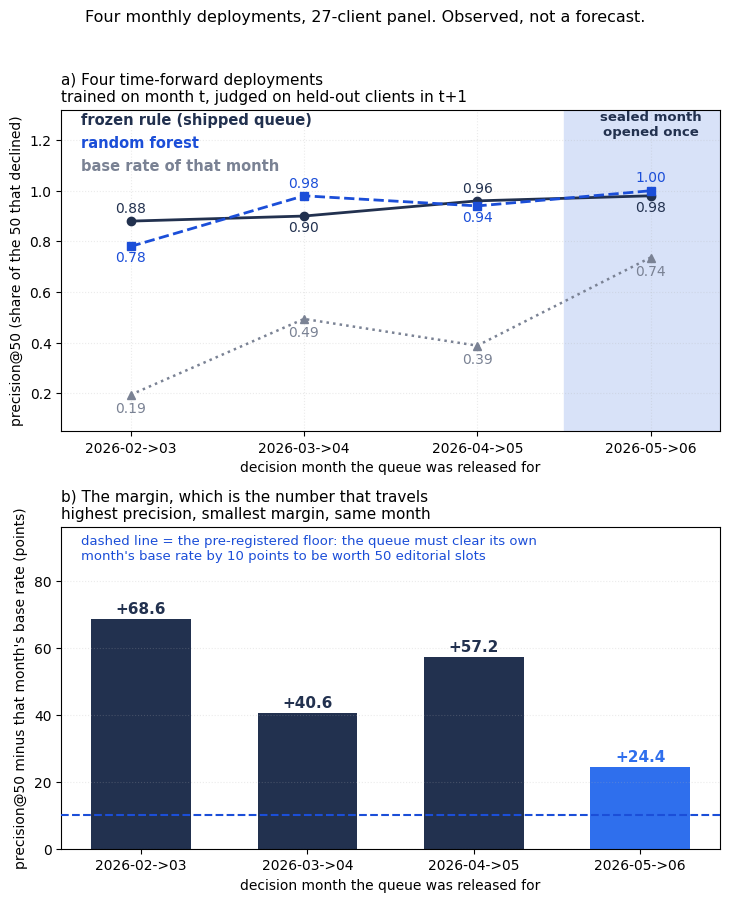

figure written to work/figures/capstone_fig1_sealed_results.png


In [16]:
# Palette: the same tokens the deployed paper uses, so the figures and the page read as one
# system. Series are distinguished by line style, marker and a direct label as well as by colour.
RULE_C, MODEL_C, BASE_C = "#22314F", "#1B4ED8", "#7A8294"   # main / accent-text / context
ACCENT, HILITE = "#2F6FED", "#D8E2F8"                       # accent fill / the highlight wash
fwd_tbl = queues.iloc[1:].reset_index(drop=True)
labels = [d.replace("forward ", "").replace("SEALED ", "") for d in fwd_tbl.deployment]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.4, 8.8))
x = np.arange(len(fwd_tbl))

# --- panel a: precision@50 and the base rate under it -------------------------------------------
ax1.axvspan(2.5, 3.5, color=HILITE, zorder=0)
ax1.plot(x, fwd_tbl.rule_p50, marker="o", ls="-", color=RULE_C, lw=2, zorder=3)
ax1.plot(x, fwd_tbl.model_p50, marker="s", ls="--", color=MODEL_C, lw=2, zorder=3)
ax1.plot(x, fwd_tbl.base_rate, marker="^", ls=":", color=BASE_C, lw=1.8, zorder=3)
for xi, (r, m, b) in enumerate(zip(fwd_tbl.rule_p50, fwd_tbl.model_p50, fwd_tbl.base_rate)):
    up = r >= m
    ax1.annotate(f"{r:.2f}", (xi, r + (0.035 if up else -0.06)), ha="center", fontsize=10, color=RULE_C)
    ax1.annotate(f"{m:.2f}", (xi, m + (-0.06 if up else 0.035)), ha="center", fontsize=10, color=MODEL_C)
    ax1.annotate(f"{b:.2f}", (xi, b - 0.07), ha="center", fontsize=10, color=BASE_C)
for i, (txt, col) in enumerate([("frozen rule (shipped queue)", RULE_C), ("random forest", MODEL_C),
                                ("base rate of that month", BASE_C)]):
    ax1.annotate(txt, xy=(0.03, 0.955 - i * 0.072), xycoords="axes fraction", fontsize=10.5,
                 color=col, weight="bold")
ax1.annotate("sealed month\nopened once", xy=(3, 1.22), ha="center", fontsize=9.5,
             color=RULE_C, weight="bold")
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=10)
ax1.set_xlim(-0.4, len(fwd_tbl) - 0.6); ax1.set_ylim(0.05, 1.32)
ax1.set_ylabel("precision@50 (share of the 50 that declined)")
ax1.set_xlabel("decision month the queue was released for")
ax1.set_title("a) Four time-forward deployments\ntrained on month t, judged on held-out clients in t+1",
              fontsize=11, loc="left")
ax1.grid(alpha=0.25, ls=":")

# --- panel b: the margin, which is the number that survives -------------------------------------
bars = ax2.bar(x, fwd_tbl.margin_pp, color=[RULE_C, RULE_C, RULE_C, ACCENT], width=0.6)
for xi, v in zip(x, fwd_tbl.margin_pp):
    ax2.text(xi, v + 1.6, f"+{v:.1f}", ha="center", fontsize=11, weight="bold",
             color=ACCENT if xi == 3 else RULE_C)
ax2.axhline(T_QUEUE_MARGIN * 100, color=MODEL_C, ls="--", lw=1.5, zorder=4)
ax2.annotate(f"dashed line = the pre-registered floor: the queue must clear its own\nmonth's base "
             f"rate by {T_QUEUE_MARGIN * 100:.0f} points to be worth 50 editorial slots",
             xy=(0.03, 0.90), xycoords="axes fraction", fontsize=9.5, color=MODEL_C)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylim(0, 96)
ax2.set_ylabel("precision@50 minus that month's base rate (points)")
ax2.set_xlabel("decision month the queue was released for")
ax2.set_title("b) The margin, which is the number that travels\nhighest precision, smallest margin, "
              "same month", fontsize=11, loc="left")
ax2.grid(axis="y", alpha=0.25, ls=":")

fig.suptitle("Four monthly deployments, 27-client panel. Observed, not a forecast.",
             fontsize=11.5, y=1.02)
fig.tight_layout()
fig1_path = fig_dir / "capstone_fig1_sealed_results.png"
fig.savefig(fig1_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"figure written to work/figures/{fig1_path.name}")

**Figure 1 caption, as the paper carries it.**

> Precision@50 for the fifty-page review queue across four time-forward monthly deployments, each
> trained on the 18 training clients in month *t* and judged on the held-out clients present in
> month *t+1* (nine of them, and eight in the first and last months, where one client has no
> scorable page). **(a)** The frozen rule, the random forest, and each month's own base rate — the share of
> pages that would decline anyway. The shaded column is the sealed release, whose label was opened
> once, after the pre-release gate had already passed it. **(b)** The same result expressed as the
> margin over that month's base rate, with the pre-registered 10-point floor that the queue must
> clear to earn fifty editorial slots.
>
> **Supports:** the queue ranked far above its month's base rate in every month observed, including
> the sealed one; and the margin, not the precision, is what stayed comparable.
> **Does not support:** that either scorer beats the other (they cross, and the interval on the
> difference contains zero); that precision is comparable *between* months; that any feature is a
> search-ranking factor; or that reviewing a queued page causes it to recover. Nothing here was an
> experiment.

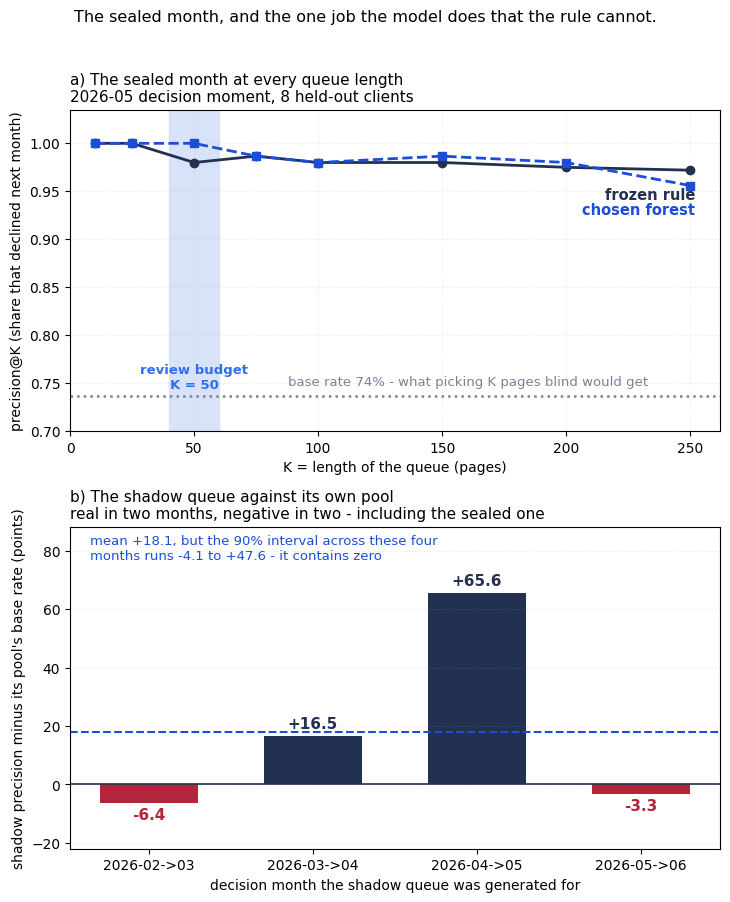

figure written to work/figures/capstone_fig2_precision_at_k.png


In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.4, 8.8))

# --- panel a: does the answer depend on the editor's exact capacity? ----------------------------
ax1.axvspan(40, 60, color=HILITE, zorder=0)
ax1.plot(curve.K, curve["frozen rule"], marker="o", ls="-", color=RULE_C, lw=2, zorder=3)
ax1.plot(curve.K, curve["chosen forest"], marker="s", ls="--", color=MODEL_C, lw=2, zorder=3)
ax1.axhline(curve["base rate"].iloc[0], color=BASE_C, ls=":", lw=1.8, zorder=2)
ax1.annotate("review budget\nK = 50", xy=(50, 0.745), ha="center", fontsize=9.5,
             color=ACCENT, weight="bold")
ax1.annotate(f"base rate {curve['base rate'].iloc[0]:.0%} - what picking K pages blind would get",
             xy=(88, curve["base rate"].iloc[0] + 0.012), fontsize=9.5, color=BASE_C)
ax1.annotate("frozen rule", xy=(252, curve["frozen rule"].iloc[-1] - 0.030), ha="right",
             fontsize=10.5, color=RULE_C, weight="bold")
ax1.annotate("chosen forest", xy=(252, curve["chosen forest"].iloc[-1] - 0.030), ha="right",
             fontsize=10.5, color=MODEL_C, weight="bold")
ax1.set_xlabel("K = length of the queue (pages)")
ax1.set_ylabel("precision@K (share that declined next month)")
ax1.set_title("a) The sealed month at every queue length\n2026-05 decision moment, 8 held-out clients",
              fontsize=11, loc="left")
ax1.set_ylim(0.70, 1.035); ax1.set_xlim(0, 262)
ax1.grid(alpha=0.25, ls=":")

# --- panel b: the shadow queue, which is where the model's only real edge lives ------------------
tfwd = trial.iloc[1:].reset_index(drop=True)
xb = np.arange(len(tfwd))
NEG_C = "#B4243A"
bcols = [RULE_C if v > 0 else NEG_C for v in tfwd.lift_pp]
ax2.bar(xb, tfwd.lift_pp, color=bcols, width=0.6)
ax2.axhline(0, color=RULE_C, lw=1.2)
ax2.axhline(tfwd.lift_pp.mean(), color=MODEL_C, ls="--", lw=1.5)
ax2.annotate(f"mean {tfwd.lift_pp.mean():+.1f}, but the 90% interval across these four\n"
             f"months runs {np.percentile(boot2, 5):+.1f} to {np.percentile(boot2, 95):+.1f} - "
             f"it contains zero",
             xy=(0.03, 0.90), xycoords="axes fraction", fontsize=9.5, color=MODEL_C)
for xi, v in zip(xb, tfwd.lift_pp):
    ax2.text(xi, v + (2.5 if v > 0 else -5.5), f"{v:+.1f}", ha="center", fontsize=11,
             weight="bold", color=RULE_C if v > 0 else NEG_C)
ax2.set_xticks(xb)
ax2.set_xticklabels([d.replace("forward ", "").replace("SEALED ", "") for d in tfwd.deployment],
                    fontsize=10)
ax2.set_ylim(-22, 88)
ax2.set_ylabel("shadow precision minus its pool's base rate (points)")
ax2.set_xlabel("decision month the shadow queue was generated for")
ax2.set_title("b) The shadow queue against its own pool\nreal in two months, negative in two - "
              "including the sealed one", fontsize=11, loc="left")
ax2.grid(axis="y", alpha=0.25, ls=":")

fig.suptitle("The sealed month, and the one job the model does that the rule cannot.",
             fontsize=11.5, y=1.02)
fig.tight_layout()
fig2_path = fig_dir / "capstone_fig2_precision_at_k.png"
fig.savefig(fig2_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"figure written to work/figures/{fig2_path.name}")

**Figure 2 caption, as the paper carries it.**

> **(a)** The sealed release (features 2026-05, label 2026-06, 8 held-out clients, 26,554 pages):
> tie-fair precision@K from K=10 to K=250 for the frozen rule and the chosen forest, against the
> month's 73.6% base rate. The shaded band is the editorial review budget, K=50 — the only K this
> lane declared in advance. **(b)** The ten-item shadow queue, which ranks inside the ~30% of
> declines the rule scores exactly zero, measured against that pool's own base rate in each of the
> four forward deployments.
>
> **Supports:** the result does not depend on the editor's capacity being exactly fifty; and the
> shadow queue beat its own pool in two months and lost to it in two, including the sealed one.
> **Does not support:** any comparison of panel (a) with a different month, because the base rate
> under the whole panel moves; any claim that the forest beats the rule (at K=50 they differ by one
> page); or a promise of a fixed number of extra catches per month from panel (b) — the interval on
> that mean contains zero.

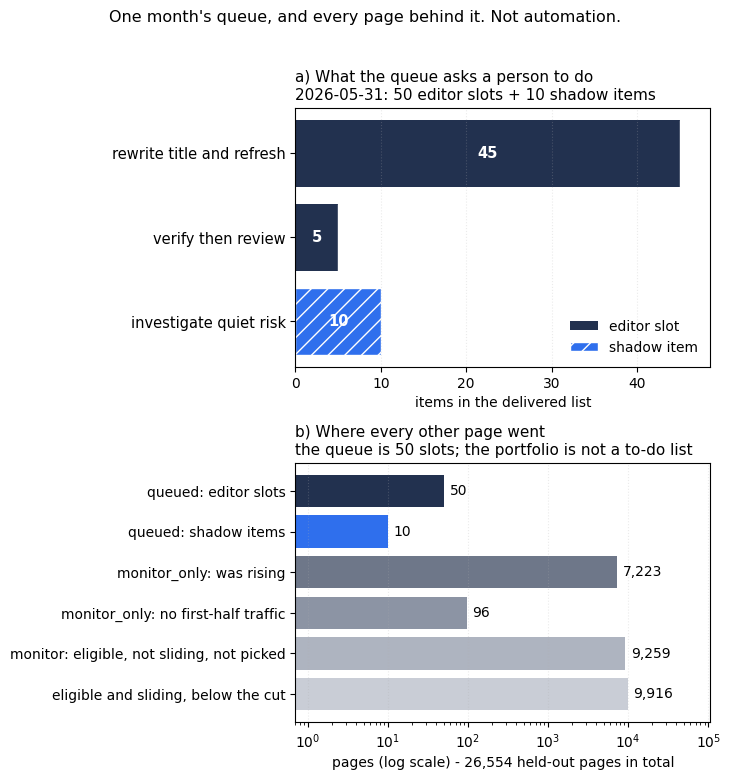

the disposition of every held-out page at the sealed decision moment:
queued: editor slots                            50
queued: shadow items                            10
monitor_only: was rising                      7223
monitor_only: no first-half traffic             96
monitor: eligible, not sliding, not picked    9259
eligible and sliding, below the cut           9916

figure written to work/figures/capstone_fig3_queue_composition.png


In [18]:
act_ed, act_sh = ed.action.value_counts(), sh.action.value_counts()
actions_order = [a for a in ["rewrite_title_and_refresh", "refresh_now", "expand_or_consolidate",
                             "verify_then_review", "investigate_quiet_risk"]
                 if a in set(act_ed.index) | set(act_sh.index)]
disposition = pd.Series({
    "queued: editor slots": len(ed),
    "queued: shadow items": len(sh),
    "monitor_only: was rising": int(POOL.gate_riser.sum()),
    "monitor_only: no first-half traffic": int(POOL.gate_no_first_half.sum()),
    "monitor: eligible, not sliding, not picked":
        int(((POOL.eligible == 1) & (POOL.action_score == 0)).sum()) - len(sh),
    "eligible and sliding, below the cut":
        int(((POOL.eligible == 1) & (POOL.action_score > 0)).sum()) - len(ed)})
assert disposition.sum() == len(POOL), "every page must land in exactly one disposition"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.4, 7.6))
y = np.arange(len(actions_order))
vals_ed = [int(act_ed.get(a, 0)) for a in actions_order]
vals_sh = [int(act_sh.get(a, 0)) for a in actions_order]
ax1.barh(y, vals_ed, color=RULE_C, label="editor slot")
ax1.barh(y, vals_sh, left=vals_ed, color=ACCENT, hatch="//", edgecolor="white", label="shadow item")
for yi, (e, s) in enumerate(zip(vals_ed, vals_sh)):
    if e:
        ax1.text(e / 2, yi, str(e), va="center", ha="center", color="white", fontsize=10.5, weight="bold")
    if s:
        ax1.text(e + s / 2, yi, str(s), va="center", ha="center", color="white", fontsize=10.5, weight="bold")
ax1.set_yticks(y); ax1.set_yticklabels([a.replace("_", " ") for a in actions_order], fontsize=10.5)
ax1.invert_yaxis(); ax1.set_xlabel("items in the delivered list")
ax1.set_xlim(0, max(e + s for e, s in zip(vals_ed, vals_sh)) * 1.08)
ax1.set_title(f"a) What the queue asks a person to do\n{SEALED_DECISION_DATE}: {len(ed)} editor slots "
              f"+ {len(sh)} shadow items", fontsize=11, loc="left")
ax1.legend(fontsize=10, frameon=False, loc="lower right")
ax1.grid(axis="x", alpha=0.25, ls=":")

colors = [RULE_C, ACCENT, "#6E7789", "#8C94A4", "#AEB4C0", "#C9CDD6"]
yy = np.arange(len(disposition))
ax2.barh(yy, disposition.values, color=colors)
for yi, v in enumerate(disposition.values):
    ax2.text(v * 1.18, yi, f"{v:,}", va="center", fontsize=10)
ax2.set_yticks(yy); ax2.set_yticklabels(disposition.index, fontsize=10)
ax2.invert_yaxis(); ax2.set_xscale("log"); ax2.set_xlim(0.7, len(POOL) * 4)
ax2.set_xlabel(f"pages (log scale) - {len(POOL):,} held-out pages in total")
ax2.set_title("b) Where every other page went\nthe queue is 50 slots; the portfolio is not a to-do list",
              fontsize=11, loc="left")
ax2.grid(axis="x", alpha=0.25, ls=":")

fig.suptitle("One month's queue, and every page behind it. Not automation.",
             fontsize=11.5, y=1.02)
fig.tight_layout()
fig3_path = fig_dir / "capstone_fig3_queue_composition.png"
fig.savefig(fig3_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("the disposition of every held-out page at the sealed decision moment:")
print(disposition.to_string())
print(f"\nfigure written to work/figures/{fig3_path.name}")
receipts["page_disposition_sealed"] = {k: int(v) for k, v in disposition.items()}

**Figure 3 caption, as the paper carries it.**

> **(a)** What one month's queue actually asks a person to do: 50 editor slots and 10 shadow items at
> the 2026-05 decision moment. Two of the four rule actions — `refresh_now` and
> `expand_or_consolidate` — do not appear at all, which is the queue's own documented design flaw
> (recommendation 8), not an omission from the chart. **(b)** Where every one of the 26,554 held-out
> pages went, on a log scale. 7,319 pages are held at `monitor_only` by the two gates and can never
> take a slot.
>
> **Supports:** the queue is fifty slots out of 26,554 pages, and most of the portfolio is
> deliberately not on it. **Does not support:** anything about outcomes — this figure is composition
> only.

In [19]:
# --- the queue CSV: what a person would have been handed on 2026-05-31, and nothing else --------
export = POOL.copy()
export["disposition"] = np.select(
    [export.gate_no_first_half == 1, export.gate_riser == 1, export.action_score > 0],
    ["monitor_only: no first-half traffic", "monitor_only: was rising", "eligible: sliding"],
    default="eligible: not sliding")
export = export.merge(QUEUE[["row_id", "slot", "slot_type", "queue", "reason_code", "action"]],
                      on="row_id", how="left")
unqueued = pd.Series(np.where(export.gate_no_first_half == 1, "new_or_no_first_half_traffic",
                     np.where(export.gate_riser == 1, "durable_riser", "holding_steady")),
                     index=export.index)
export["reason_code"] = export.reason_code.fillna(unqueued)
export["action"] = export.action.fillna(export.reason_code.map(ACTIONS))
export = export.merge(PLAYBOOK[["reason_code", "archetype", "guardrail"]], on="reason_code", how="left")
export["rule_rank"] = export.action_score.rank(ascending=False, method="first").astype(int)
export = export.sort_values(["slot", "rule_rank"], na_position="last")

QUEUE_COLS = ["slot", "slot_type", "queue", "rule_rank", "disposition", "reason_code", "archetype",
              "action", "guardrail", "action_score", "model_rank_pct", "client_hash_id",
              "content_hash_id", "imp_mar", "pos_mar", "ctr_mar", "momentum_in_month", "active_days",
              "spike_share", "gate_no_first_half", "gate_riser", "gate_verify"]
assert not any(c in QUEUE_COLS for c in ["label_declining", "imp_next", "seen_next_month"]), \
    "the delivered queue must not carry the outcome it is judged by"
csv_path = out_dir / "capstone_sealed_queue.csv"
export[QUEUE_COLS].round(6).to_csv(csv_path, index=False)
print(f"queue written to work/outputs/{csv_path.name}: {len(export):,} rows x {len(QUEUE_COLS)} columns")
print(f"  {int(export.slot.notna().sum())} carry a slot ({len(ed)} editor + {len(sh)} shadow); the rest "
      f"carry a disposition and no action")
print("  regenerated on every run and gitignored by design (work/**/*.csv) - no dataset enters git")
print("\nhead of the file, ids withheld from the printout:")
print(export[QUEUE_COLS].drop(columns=["client_hash_id", "content_hash_id", "guardrail", "archetype"])
      .head(4).round(3).to_string(index=False))

# --- the result -> section map the paper quotes from -------------------------------------------
RESULT_MAP = pd.DataFrame([
    ("sealed precision@50 = 0.98 (base rate 0.736, margin +24.4pp)", "capstone s4a", "new: the sealed release"),
    ("four forward deployments: 0.88 / 0.90 / 0.96 / 0.98", "capstone s4a", "w06 rung D + the sealed month"),
    ("model minus rule: mean -0.5pp, 90% interval -6.0 to +5.0", "capstone s4d", "w05 tie, w06 interval, extended"),
    ("trial lift over its own pool: -6.4 / +16.5 / +65.6 / -3.3 points", "capstone s4d", "w05 blind spot, re-measured"),
    ("pre-release gate passed the release without labels", "capstone s3c", "w07 pre-registered thresholds"),
    ("A3 fired on a +34.8pp base-rate move; A5 and A6 fired; no promotion", "capstone s4d", "w07 decision rules"),
    ("disclosed gap: month-over-month PSI on pos_mar 0.4224, alarm could not see it", "capstone s3c/s4e", "new"),
    ("precision@50 saturates: honest and leaked models both score 1.00", "capstone s4d", "new"),
    ("queue recall 0.25% of declines, 2.3% of lost impressions", "capstone s5", "new"),
    ("figure: four deployments + the margin", "capstone s7", "work/figures/capstone_fig1_sealed_results.png"),
    ("figure: precision@K + the shadow queue's lift by month", "capstone s7", "work/figures/capstone_fig2_precision_at_k.png"),
    ("figure: action mix + page disposition", "capstone s7", "work/figures/capstone_fig3_queue_composition.png"),
], columns=["number the paper prints", "where it is computed", "what it traces back to"])
print("\n\nRESULT -> SECTION MAP (the paper's reproducibility route starts here)")
print(RESULT_MAP.to_string(index=False))

receipts["result_map"] = RESULT_MAP.to_dict("records")
receipts["exports"] = {"queue_csv": f"work/outputs/{csv_path.name} (regenerated, gitignored)",
                       "figures": [f"work/figures/{p.name}" for p in (fig1_path, fig2_path, fig3_path)],
                       "receipts_json": "work/outputs/capstone_receipts.json (committed)"}
receipts["environment"] = {"python": sys.version.split()[0], "numpy": np.__version__,
                           "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                           "duckdb": duckdb.__version__, "matplotlib": matplotlib.__version__,
                           "warehouse_build": "v20260703", "seed": SEED}
receipts["verdict"] = (
    "on a sealed month neither scorer had seen, the frozen hand-written rule filled a 50-page review "
    "queue at precision@50 = 0.98 against a 0.736 base rate (+24.4 points, the smallest margin of "
    "four forward deployments and the highest precision); the random forest scored 1.00 on the same "
    "pool, a one-page difference inside an interval that contains zero across four months; the "
    "pre-registered promotion rule declined to give the model editorial slots for the third time in "
    "four months, and the queue ships as 50 rule slots plus 10 measured shadow items")

rec_path = out_dir / "capstone_receipts.json"
rec_path.write_text(json.dumps(receipts, indent=2, default=str), encoding="utf-8")
print(f"\nreceipts written to work/outputs/{rec_path.name} ({len(receipts)} top-level entries)")
print(json.dumps({k: receipts[k] for k in ["policy_decisions", "uncertainty", "verdict"]},
                 indent=2, default=str))

queue written to work/outputs/capstone_sealed_queue.csv: 26,554 rows x 22 columns
  60 carry a slot (50 editor + 10 shadow); the rest carry a disposition and no action
  regenerated on every run and gitignored by design (work/**/*.csv) - no dataset enters git

head of the file, ids withheld from the printout:
 slot   slot_type  queue  rule_rank       disposition                reason_code                    action  action_score  model_rank_pct  imp_mar  pos_mar  ctr_mar  momentum_in_month  active_days  spike_share  gate_no_first_half  gate_riser  gate_verify
  1.0 editor_slot A_rule          1 eligible: sliding slipping_and_underclicking rewrite_title_and_refresh        31.220            99.8  54022.0    6.223    0.000              0.036           31        0.084                   0           0            0
  2.0 editor_slot A_rule          2 eligible: sliding slipping_and_underclicking rewrite_title_and_refresh        30.569            99.1  53184.0    9.970    0.000              0.05

---

## ML-12 — Telling the story

The same work, retold three ways. Nothing below introduces a number that is not computed above.

### The 5-minute demo outline

**0:00 — The problem, in one real scenario (45s).**
One FlyRank editor, one morning a month, a portfolio of tens of thousands of pages, and capacity for
about fifty. Today the shortlist is instinct. Show the arithmetic from section 1: 50 slots against
82,570 scorable pages — 0.06% of the portfolio. *"The question is never which pages are declining.
It's which fifty first."*

**0:45 — The method, in three sentences (60s).**
Score every page at the close of the month on five things it did that month — size, live days, rank,
click-through, and whether its second half ran below its first. Label = it lost more than 20% of its
impressions the following month. Compare a hand-written rule against a random forest on **the same
held-out clients, in the same run**, at precision@50, because fifty is the editorial budget.
Name the one thing that makes this honest: the split is grouped by client *and* forward in time, so
the model meets clients it never trained on, in a month that had not happened yet.

**1:45 — One chart (90s).** Figure 1. Walk the four points left to right: 0.88, 0.90, 0.96, 0.98 —
then point at the row underneath. *"The base rates are 0.19, 0.49, 0.39, 0.74. The last month looks
like our best result and it's our smallest margin: +24 points against +69 at the start. The number
that travels is panel (b), not panel (a)."*

**3:15 — One honest result (60s).**
*"The model did not beat the rule. Across four forward deployments the difference is minus ten, plus
eight, minus two, plus two points — mean minus a half point, and the interval contains zero. I
pre-registered a promotion rule in week 7 and ran it once on a sealed month. It said don't promote.
I didn't edit it afterwards — and running it as written is how I found that my own drift alarm was
looking at the wrong comparison and missed a PSI of 0.42."*

**4:15 — One recommendation, and the limit (45s).**
Ship the rule; keep the model in shadow; report the margin, never the bare precision. Then the limit,
out loud: one client is 90% of the sealed pool, the fifty slots cover a quarter of one percent of
that month's declines, and nothing here was an experiment, so nothing here is causal. *"It's triage
for one person's afternoon. It's honest work at exactly that size."*

**Q&A bait, left deliberately:** why the rule protects 4× more traffic than the model at the same
precision; and why precision@50 could not tell an honest model from one handed the answer.

### The social post cut

> I spent eight weeks building a "predict which pages will lose traffic" model on 79M rows of real
> daily search-console data. The headline result: **my hand-written rule beat it.**
>
> Across four month-to-month deployments on held-out clients, the rule filled a 50-page editorial
> review queue at precision@50 of 0.88 / 0.90 / 0.96 / 0.98. A tuned random forest on the same five
> features, same rows, same run: −10 / +8 / −2 / +2 points against it. Mean difference: half a point
> the wrong way, with a bootstrap interval that comfortably contains zero.
>
> The part I'd actually put on a slide isn't the model comparison. It's this: my best precision came
> in the month where it meant the least. Precision went 0.96 → 0.98; the base rate under it went
> 0.39 → 0.74. The margin over "what picking 50 pages blind would get" *fell* from +57 points to
> +24. Same queue, better-looking number, easier month.
>
> Method in one line: features from month *t* only, label from month *t+1*, split grouped by client
> **and** forward in time, thresholds pre-registered before the final month was opened — and then run
> once, as written, on a month I had never looked at. Running my own rule unedited is how I found
> that my drift alarm was reading the wrong comparison and sailed past a PSI of 0.42.
>
> Full paper, notebooks and receipts: [link]. Built on the FlyRank ML Internship dataset.

### The employer-facing summary (three sentences)

> I built a monthly triage queue that ranks a client portfolio of 82,570 scorable pages by which
> ones are about to lose search traffic, on a 79-million-row daily search-performance fact table, and
> validated it with a split that is grouped by client *and* forward in time — plus one sealed month
> opened exactly once, against thresholds I wrote down a week before I was allowed to look. On that sealed month the
> shipped queue put 49 correct pages in an editor's first 50 against a 73.6% base rate, and the
> tuned random forest I spent a week on came in one page ahead — a difference an interval across
> four deployments cannot separate from zero, so I shipped the readable rule and kept the model in a
> measured shadow queue. The result I'm proudest of is the one that cost me the headline: precision
> rose while the margin over the base rate fell by more than half, and saying so is the difference
> between a dashboard and a finding.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.